# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [60]:
#Type your code here
import warnings
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)

from sklearn import metrics
from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [61]:
#Type your code here
# Load dataset
df = pd.read_csv('Dataset_inisiasi.csv', encoding='Latin-1')

In [62]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125.0,B,Major,80.0,89.0,83.0,31.0,0.0,8.0,4.0
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92.0,C#,Major,71.0,61.0,74.0,7.0,0.0,10.0,4.0
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138.0,F,Major,51.0,32.0,53.0,17.0,0.0,31.0,6.0
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170.0,A,Major,55.0,58.0,72.0,11.0,0.0,11.0,15.0
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144.0,A,Minor,65.0,23.0,80.0,14.0,63.0,11.0,6.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [63]:
#Type your code here
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125.0,B,Major,80.0,89.0,83.0,31.0,0.0,8.0,4.0
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92.0,C#,Major,71.0,61.0,74.0,7.0,0.0,10.0,4.0
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138.0,F,Major,51.0,32.0,53.0,17.0,0.0,31.0,6.0
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170.0,A,Major,55.0,58.0,72.0,11.0,0.0,11.0,15.0
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144.0,A,Minor,65.0,23.0,80.0,14.0,63.0,11.0,6.0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            2859 non-null   object 
 1   artist(s)_name        2859 non-null   object 
 2   artist_count          2859 non-null   int64  
 3   released_year         2859 non-null   int64  
 4   released_month        2859 non-null   int64  
 5   released_day          2859 non-null   int64  
 6   in_spotify_playlists  2859 non-null   int64  
 7   in_spotify_charts     2859 non-null   int64  
 8   streams               2859 non-null   object 
 9   in_apple_playlists    2859 non-null   int64  
 10  in_apple_charts       2859 non-null   int64  
 11  in_deezer_playlists   2859 non-null   object 
 12  in_deezer_charts      2859 non-null   int64  
 13  in_shazam_charts      2809 non-null   object 
 14  bpm                   2859 non-null   float64
 15  key                  

In [65]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000,2859.000000
mean,2.520811,2009.463099,6.363064,15.333333,3425.762504,10.245890,125.861490,23.601259,3.932494,121.174241,67.655503,57.409159,63.501822,32.081555,13.750215,24.817322,14.332153
std,1.448620,15.687118,3.492125,8.920913,4870.389572,12.280375,94.063446,35.730277,4.303073,23.424024,17.247462,17.006686,18.214702,23.270024,16.650160,16.828887,8.681475
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.000000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2004.000000,3.000000,8.000000,1152.500000,2.000000,41.000000,5.000000,0.000000,100.000000,52.000000,46.956685,48.000000,12.000000,0.000000,11.000000,7.000000
50%,2.000000,2014.000000,6.000000,15.000000,2474.000000,8.000000,110.000000,11.000000,3.000000,122.000000,70.000000,58.511759,67.000000,23.331551,5.509935,17.297262,12.619304
75%,4.000000,2021.000000,9.000000,23.000000,3966.000000,14.000000,199.500000,18.000000,7.000000,140.161861,82.906166,70.221911,79.444858,52.501298,28.338830,38.605644,20.882223
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,58.000000,206.000000,96.000000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


In [66]:
df.isnull().sum()

track_name                0
artist(s)_name            0
artist_count              0
released_year             0
released_month            0
released_day              0
in_spotify_playlists      0
in_spotify_charts         0
streams                   0
in_apple_playlists        0
in_apple_charts           0
in_deezer_playlists       0
in_deezer_charts          0
in_shazam_charts         50
bpm                       0
key                     286
mode                      0
danceability_%            0
valence_%                 0
energy_%                  0
acousticness_%            0
instrumentalness_%        0
liveness_%                0
speechiness_%             0
dtype: int64

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [67]:
# Mengisi nilai yang hilang dalam kolom 'key' dengan 'Unknown'
df['key'] = df['key'].fillna('Unknown')

# Mengisi nilai yang hilang dalam kolom 'in_shazam_charts' dengan 0
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)

# Mengubah tipe data kolom 'in_deezer_playlists', 'in_shazam_charts', dan 'streams' menjadi string
df[['in_deezer_playlists', 'in_shazam_charts', 'streams']] = df[['in_deezer_playlists', 'in_shazam_charts', 'streams']].astype('str').astype('string')

# Menghapus tanda koma dari kolom 'in_deezer_playlists' dan 'in_shazam_charts'
df['in_deezer_playlists'] = df['in_deezer_playlists'].replace(',', '', regex=True)
df['in_shazam_charts'] = df['in_shazam_charts'].replace(',', '', regex=True)

# Mengganti nilai yang salah dalam kolom 'streams' dengan '0'
df['streams'] = df['streams'].replace('BPM110KeyAModeMajorDanceability53Valence75Energy69Acousticness7Instrumentalness0Liveness17Speechiness3', '0')

# Mengubah kolom ke tipe numerik dan menangani error dengan mengubahnya menjadi NaN
df['in_deezer_playlists'] = pd.to_numeric(df['in_deezer_playlists'], errors='coerce')
df['in_shazam_charts'] = pd.to_numeric(df['in_shazam_charts'], errors='coerce')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Mengisi nilai NaN yang muncul akibat konversi ke numerik dengan 0
df['in_deezer_playlists'] = df['in_deezer_playlists'].fillna(0)
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)
df['streams'] = df['streams'].fillna(0)

# Mengubah tipe data kolom menjadi int64 untuk menangani angka besar
df['in_deezer_playlists'] = df['in_deezer_playlists'].astype('int64')
df['in_shazam_charts'] = df['in_shazam_charts'].astype('int64')
df['streams'] = df['streams'].astype('int64')

In [68]:
# Jumlah track unik
print(f'Number of tracks : {df.track_name.nunique()}')

# Jumlah artis unik
print(f'Number of artist(s) : {df["artist(s)_name"].nunique()}')

# Perbandingan jumlah track dan artis
if df.track_name.nunique() < len(df):
    print(f'There are {df.track_name.nunique()} tracks meanwhile the data has {len(df)} entries, so there are some tracks which come from different artist(s).')
else:
    print('The tracks are unique.')


Number of tracks : 943
Number of artist(s) : 645
There are 943 tracks meanwhile the data has 2859 entries, so there are some tracks which come from different artist(s).


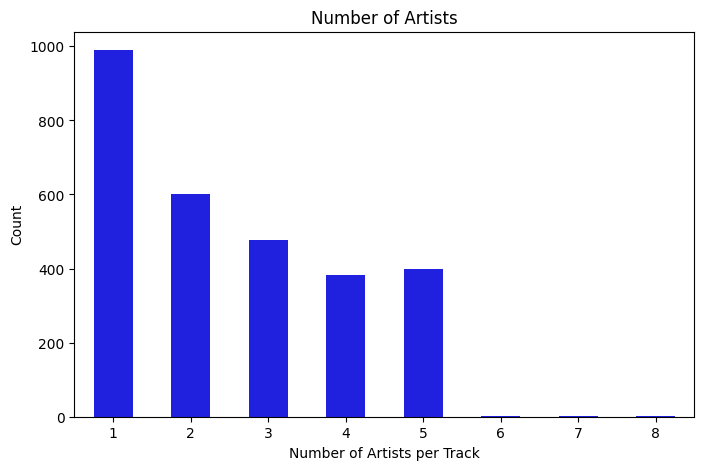

In [69]:
# Visualisasi distribusi jumlah artis dalam dataset
plt.figure(figsize=(8, 5))  # Menentukan ukuran figure
sns.countplot(data=df, x='artist_count', color='blue', width=0.5)  # Membuat countplot dengan warna biru
plt.title('Number of Artists')  # Menambahkan judul grafik
plt.xlabel('Number of Artists per Track')  # Menambahkan label sumbu X
plt.ylabel('Count')  # Menambahkan label sumbu Y
plt.show()  # Menampilkan grafik


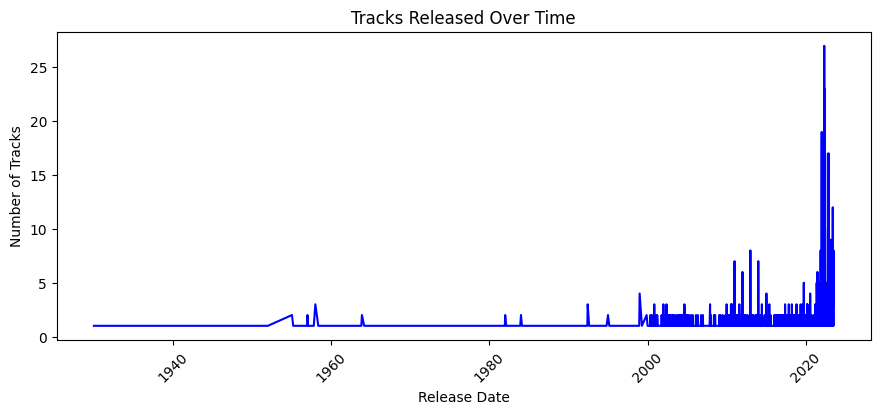

In [70]:
# 1. Membuat kolom 'released_date' dengan format datetime dari tiga kolom: 'released_year', 'released_month', dan 'released_day'
df['released_date'] = pd.to_datetime(df['released_year'].astype(str) + '-' +
                                     df['released_month'].astype(str) + '-' +
                                     df['released_day'].astype(str))

# 2. Menghitung jumlah lagu yang dirilis pada setiap tanggal unik
count_per_time = df['released_date'].value_counts().reset_index()
count_per_time.columns = ['released_date', 'count']  # Menetapkan nama kolom agar lebih jelas

# 3. Membuat visualisasi jumlah lagu yang dirilis berdasarkan tanggal
plt.figure(figsize=(10.5, 4))  # Menentukan ukuran figure
sns.lineplot(data=count_per_time, x='released_date', y='count', color='blue')  # Membuat line plot dengan warna biru
plt.title('Tracks Released Over Time')  # Menambahkan judul grafik
plt.xlabel('Release Date')  # Menambahkan label sumbu X
plt.ylabel('Number of Tracks')  # Menambahkan label sumbu Y
plt.xticks(rotation=45)  # Memiringkan label tanggal agar lebih mudah dibaca
plt.show()  # Menampilkan grafik


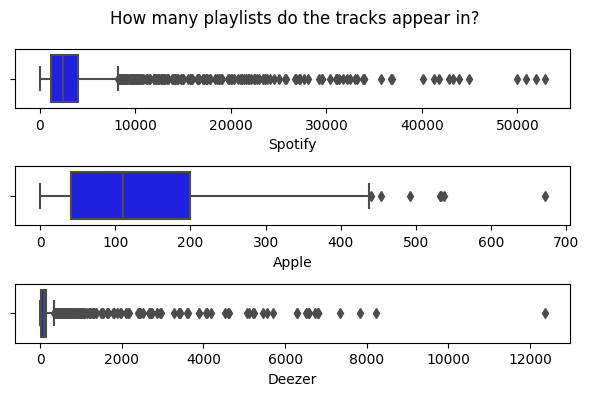

In [71]:
# 1. Menentukan kolom yang menunjukkan jumlah playlist tempat lagu dimasukkan
in_playlists = list(df[['in_spotify_playlists', 'in_apple_playlists', 'in_deezer_playlists']].columns)

# 2. Membuat subplot dengan 3 baris dan 1 kolom untuk menampilkan distribusi jumlah track di setiap platform
fig, axes = plt.subplots(3, 1, figsize=(6, 4))  # Ukuran figure 6x4 dengan 3 subplots

# 3. Melakukan iterasi untuk setiap kolom (platform) dan membuat boxplot
for col, ax in zip(in_playlists, axes.ravel()):
    sns.boxplot(data=df, x=col, ax=ax, color='blue')  # Mengubah warna plot menjadi biru untuk konsistensi

# 4. Menambahkan judul utama untuk semua subplot
fig.suptitle('How many playlists do the tracks appear in?')

# 5. Memberikan label pada setiap sumbu X agar lebih informatif
axes[0].set_xlabel('Spotify')  # Label untuk subplot pertama
axes[1].set_xlabel('Apple')    # Label untuk subplot kedua
axes[2].set_xlabel('Deezer')   # Label untuk subplot ketiga

# 6. Mengatur tata letak agar tidak ada tumpang tindih antar elemen
plt.tight_layout()

# 7. Menampilkan plot
plt.show()


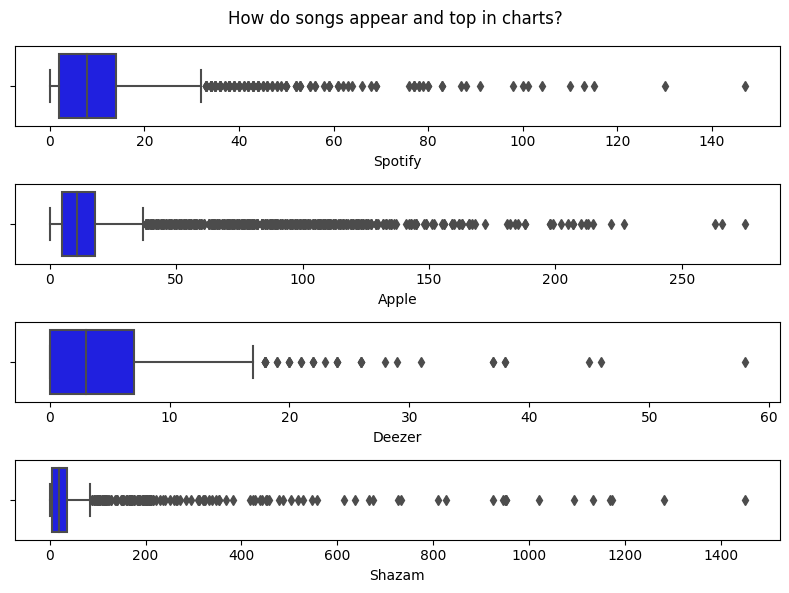

In [72]:
# 1. Menentukan kolom yang menunjukkan jumlah lagu yang masuk dalam berbagai chart platform
in_charts = list(df[['in_spotify_charts', 'in_apple_charts', 'in_deezer_charts', 
                     'in_shazam_charts']].columns)

# 2. Membuat subplot dengan 4 baris dan 1 kolom untuk menampilkan distribusi lagu di berbagai chart
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 6))  # Ukuran figure 8x6 dengan 4 subplots

# 3. Melakukan iterasi untuk setiap kolom (platform) dan membuat boxplot
for col, ax in zip(in_charts, axes.ravel()):
    sns.boxplot(data=df, x=col, ax=ax, color='blue')  # Mengubah warna plot menjadi biru untuk konsistensi

# 4. Menambahkan judul utama untuk semua subplot
fig.suptitle('How do songs appear and top in charts?')

# 5. Memberikan label pada setiap sumbu X agar lebih informatif
axes[0].set_xlabel('Spotify')  # Label untuk subplot pertama
axes[1].set_xlabel('Apple')    # Label untuk subplot kedua
axes[2].set_xlabel('Deezer')   # Label untuk subplot ketiga
axes[3].set_xlabel('Shazam')   # Label untuk subplot keempat

# 6. Mengatur tata letak agar tidak ada tumpang tindih antar elemen
plt.tight_layout()

# 7. Menampilkan plot
plt.show()


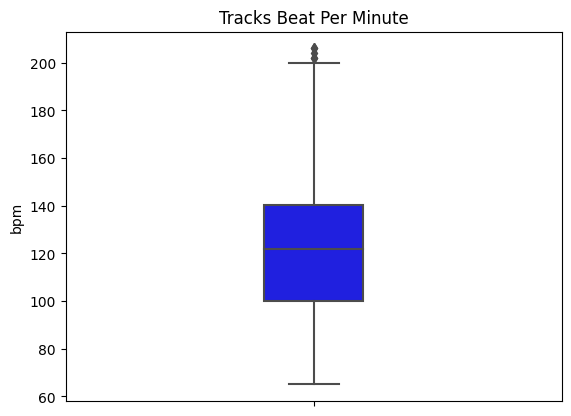

In [73]:
# Membuat boxplot untuk melihat distribusi BPM (Beat Per Minute) lagu-lagu dalam dataset
ax = sns.boxplot(data=df, y='bpm', color='blue', width=0.2)  # Mengubah warna menjadi biru dan menyesuaikan lebar
plt.title('Tracks Beat Per Minute')  # Menambahkan judul pada plot
plt.show()  # Menampilkan plot


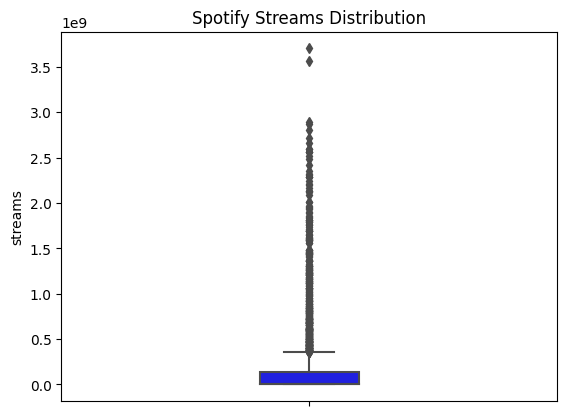

In [74]:
# Membuat boxplot untuk melihat distribusi jumlah streaming di Spotify
sns.boxplot(data=df, y='streams', color='blue', width=0.2)  # Mengubah warna menjadi biru dan menyesuaikan lebar
plt.title('Spotify Streams Distribution')  # Menambahkan judul pada plot
plt.show()  # Menampilkan plot


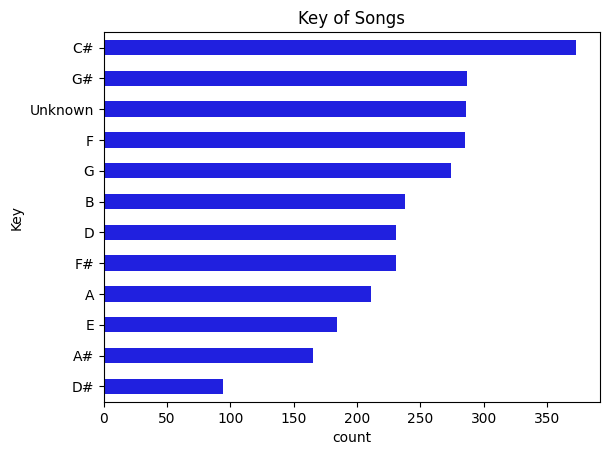

In [75]:
# Membuat countplot untuk melihat distribusi nada dasar (key) dari lagu-lagu
sns.countplot(
    data=df, 
    y='key', 
    color='blue',  # Mengubah warna menjadi biru
    order=df['key'].value_counts().index,  # Mengurutkan berdasarkan jumlah kemunculan
    width=0.5  # Menyesuaikan lebar bar
).set(title='Key of Songs', ylabel='Key')  # Menambahkan judul dan label sumbu y

plt.show()  # Menampilkan plot


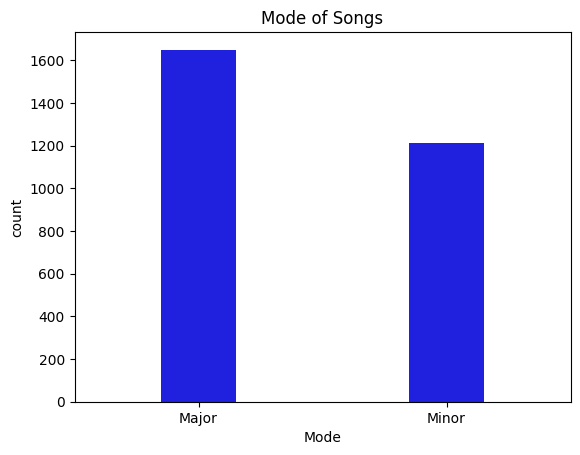

In [76]:
# Membuat countplot untuk melihat distribusi mode lagu (Mayor/Minor)
sns.countplot(
    data=df, 
    x='mode', 
    color='blue',  # Mengubah warna menjadi biru
    width=0.3  # Menyesuaikan lebar bar
).set(title='Mode of Songs', xlabel="Mode")  # Menambahkan judul dan label sumbu x

plt.show()  # Menampilkan plot


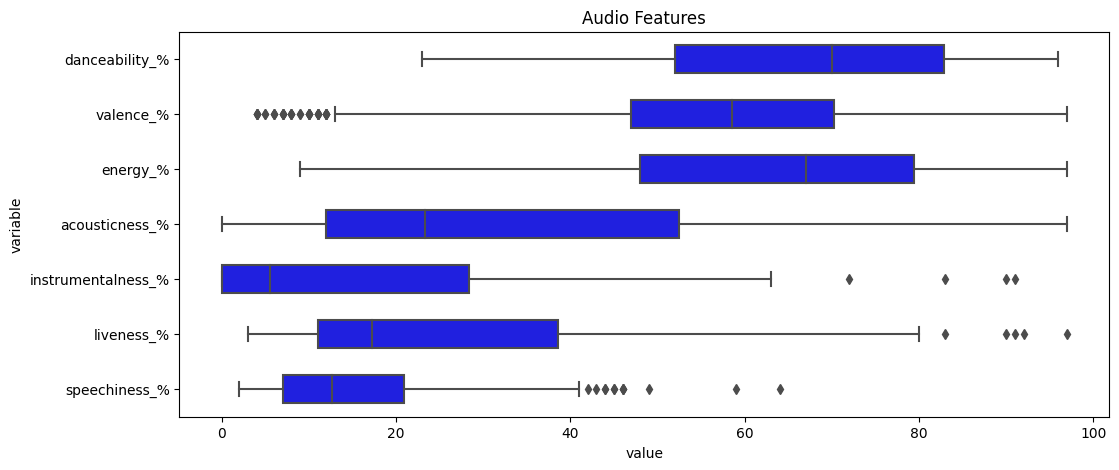

In [77]:
# Visualisasi fitur audio dalam satu sumbu karena memiliki rentang nilai yang sama (0-100)
fig = plt.figure(figsize=(12, 5))  # Mengatur ukuran figure

# Mengubah dataset ke format long agar bisa digunakan untuk boxplot
music_el = pd.melt(df[['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 
                        'instrumentalness_%', 'liveness_%', 'speechiness_%']])

# Membuat boxplot untuk melihat distribusi fitur audio
sns.boxplot(
    y='variable',  # Sumbu y berisi nama fitur
    x='value',  # Sumbu x berisi nilai fitur
    data=music_el,  
    color='blue',  # Mengubah warna menjadi biru
    width=0.5  # Menyesuaikan lebar box
).set(title='Audio Features')  # Menambahkan judul

plt.show()  # Menampilkan plot


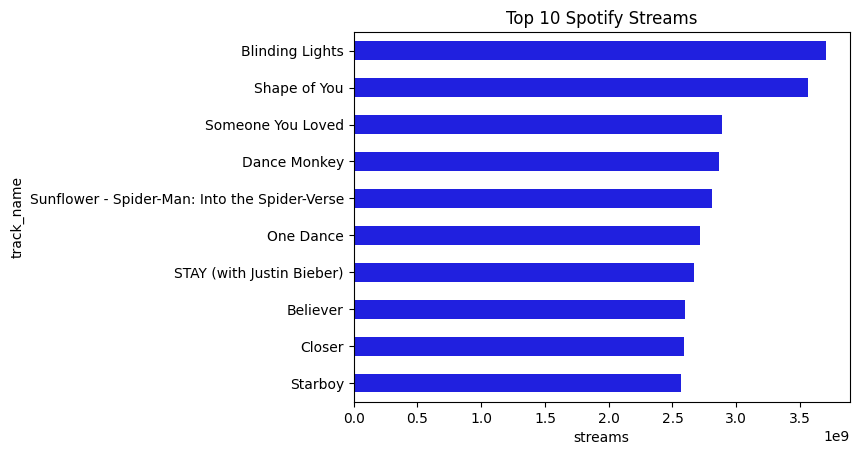

In [78]:
# Visualisasi lagu dengan jumlah stream tertinggi di Spotify
total_streams = df.groupby('track_name')['streams'].sum().reset_index()  # Mengelompokkan data berdasarkan lagu dan menjumlahkan stream
total_streams = total_streams.sort_values(by='streams', ascending=False)  # Mengurutkan dari jumlah stream tertinggi

# Membuat barplot untuk 10 lagu dengan jumlah stream tertinggi
sns.barplot(
    data=total_streams[:10],  # Mengambil 10 lagu teratas
    y='track_name',  # Sumbu y berisi nama lagu
    x='streams',  # Sumbu x berisi jumlah stream
    color='blue',  # Mengubah warna menjadi biru
    width=0.5  # Menyesuaikan lebar bar
).set(title='Top 10 Spotify Streams')  # Menambahkan judul

plt.show()  # Menampilkan plot


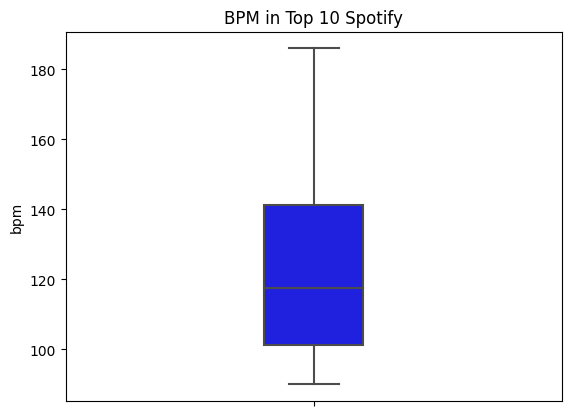

In [79]:
# Memfilter dataset untuk hanya menyertakan 10 lagu dengan jumlah stream tertinggi
top10 = df[df['track_name'].isin(total_streams['track_name'][:10])]

# Membuat boxplot untuk melihat distribusi BPM (beats per minute) dari 10 lagu teratas
sns.boxplot(
    data=top10,  
    y='bpm',  # Sumbu y berisi BPM
    color='blue',  # Mengubah warna menjadi biru
    width=0.2  # Menyesuaikan lebar boxplot
).set(title='BPM in Top 10 Spotify')  # Menambahkan judul

plt.show()  # Menampilkan plot


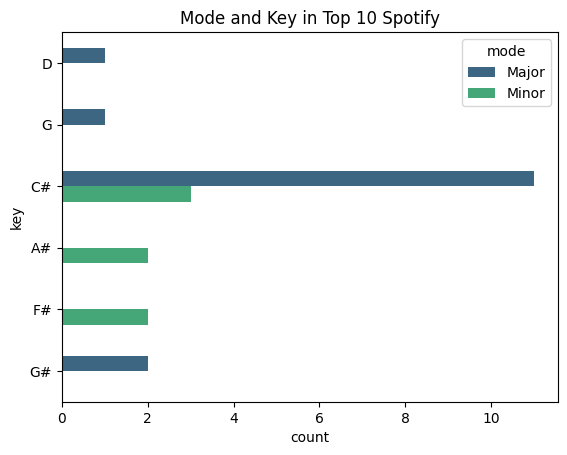

In [80]:
# Membuat countplot untuk menampilkan distribusi Key berdasarkan Mode di Top 10 Spotify
sns.countplot(
    data=top10, 
    y='key',  # Menampilkan key (nada dasar) pada sumbu Y
    hue='mode',  # Pewarnaan berdasarkan mode (Major/Minor)
    palette='viridis',  # Menggunakan palet warna yang lebih jelas
    width=0.5  # Menyesuaikan lebar bar
).set(title='Mode and Key in Top 10 Spotify')  # Menambahkan judul

plt.show()  # Menampilkan plot


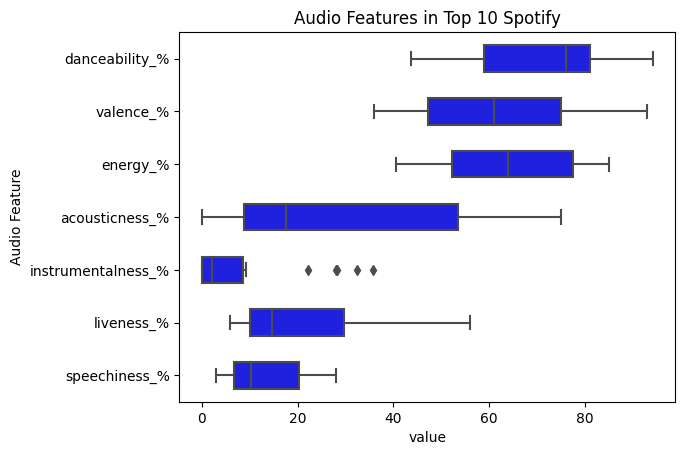

In [81]:
# Mengubah dataframe menjadi format panjang (long format) 
# agar fitur audio dapat diplot dalam satu grafik
music_top10 = pd.melt(top10[['danceability_%', 'valence_%', 'energy_%', 
                              'acousticness_%', 'instrumentalness_%', 
                              'liveness_%', 'speechiness_%']])

# Membuat boxplot untuk menampilkan distribusi fitur audio dalam Top 10 lagu Spotify
sns.boxplot(
    y='variable',  # Menampilkan nama fitur audio pada sumbu Y
    x='value',  # Menampilkan nilai fitur pada sumbu X
    data=music_top10,  # Menggunakan data yang sudah diformat
    color='blue',  # Mengubah warna plot menjadi biru
    width=0.5  # Menyesuaikan lebar boxplot
).set(
    title='Audio Features in Top 10 Spotify',  # Menambahkan judul grafik
    ylabel="Audio Feature"  # Label untuk sumbu Y
)

# Menampilkan plot
plt.show()


In [82]:
# Menambahkan kolom 'streams_playlist_ratio' untuk menghitung rasio jumlah playlist Spotify terhadap jumlah stream
top10['streams_playlist_ratio'] = top10['in_spotify_playlists'] / top10['streams']

# Mengurutkan lagu berdasarkan rasio 'streams_playlist_ratio' dari yang tertinggi ke terendah
ratio_ordered = top10[['track_name', 'streams_playlist_ratio']].sort_values(by='streams_playlist_ratio', ascending=False)

# Menampilkan hasil tabel yang berisi track name dan rasio stream terhadap playlist
print(ratio_ordered)


                                         track_name  streams_playlist_ratio
1975                              Someone You Loved                0.201836
2780                                   Shape of You                0.171951
1469                                Blinding Lights                0.079559
1552                                   Shape of You                0.079253
1346                      STAY (with Justin Bieber)                0.065878
2772                                      One Dance                0.049825
1611                                       Believer                0.043366
1834                                   Dance Monkey                0.031603
1856                                      One Dance                0.026069
1039                                         Closer                0.009603
1482                      STAY (with Justin Bieber)                0.002859
2315                                Blinding Lights                0.001657
162         

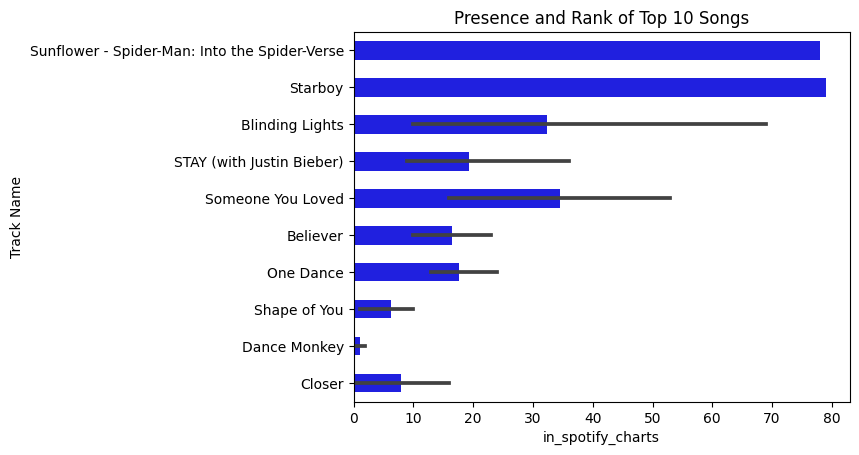

In [83]:
# Membuat bar plot untuk melihat seberapa sering lagu-lagu Top 10 muncul di Spotify Charts
sns.barplot(
    data=top10, 
    y='track_name', 
    x='in_spotify_charts', 
    width=0.5, 
    color='blue'  # Mengubah warna plot menjadi biru
).set(title='Presence and Rank of Top 10 Songs', ylabel="Track Name")

# Menampilkan plot
plt.show()


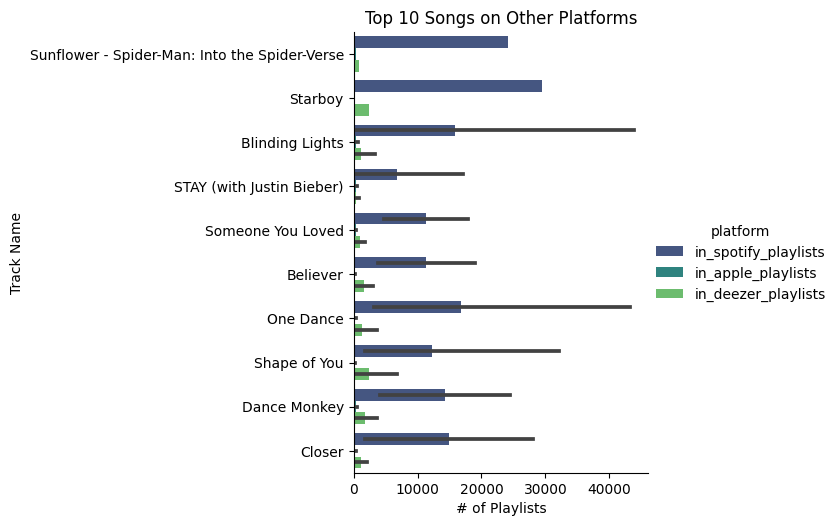

In [84]:
# Membandingkan jumlah playlist tempat lagu-lagu Top 10 muncul di berbagai platform
platform_comparison = top10[['track_name', 'in_spotify_playlists', 'in_apple_playlists', 'in_deezer_playlists']]

# Mengubah format data agar lebih mudah untuk dibandingkan dalam visualisasi
top_dp = pd.melt(platform_comparison, id_vars='track_name', var_name='platform', value_name='Number of playlists')

# Membuat bar plot untuk membandingkan jumlah playlist di setiap platform menggunakan palet warna viridis
sns.catplot(
    y='track_name', 
    x='Number of playlists', 
    hue='platform', 
    data=top_dp, 
    kind='bar', 
    aspect=.74, 
    palette='viridis'  # Menggunakan palet warna viridis untuk plot
).set(title='Top 10 Songs on Other Platforms', xlabel='# of Playlists', ylabel="Track Name")

# Menampilkan plot
plt.show()


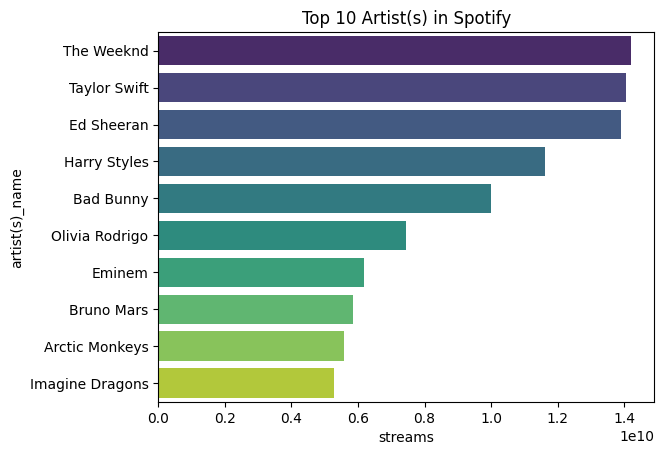

In [85]:
# Mengelompokkan data berdasarkan nama artis dan menghitung total jumlah stream per artis
top_streams_artist = df.groupby('artist(s)_name')['streams'].sum().reset_index()

# Mengurutkan artis berdasarkan jumlah stream dari yang tertinggi ke terendah
top_streams_artist = top_streams_artist.sort_values(by='streams', ascending=False)

# Membuat bar plot untuk menampilkan 10 artis dengan jumlah stream tertinggi
sns.barplot(
    data=top_streams_artist[:10],  # Mengambil 10 artis teratas
    y='artist(s)_name', 
    x='streams', 
    palette='viridis'  # Menggunakan palet warna viridis
)

# Menambahkan judul plot
plt.title('Top 10 Artist(s) in Spotify')

# Menampilkan plot
plt.show()


In [86]:
# Memfilter dataset berdasarkan 10 artis teratas berdasarkan jumlah streams
top10_ar = df[df['artist(s)_name'].isin(top_streams_artist['artist(s)_name'][:10])]

# Menampilkan dataset hasil filter
top10_ar


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,released_date
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138.000000,F,Major,51.000000,32.000000,53.000000,17.000000,0.000000,31.000000,6.000000,2023-06-30
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170.000000,A,Major,55.000000,58.000000,72.000000,11.000000,0.000000,11.000000,15.000000,2019-08-23
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144.000000,A,Minor,65.000000,23.000000,80.000000,14.000000,63.000000,11.000000,6.000000,2023-05-18
14,As It Was,Harry Styles,1,2022,3,31,23575,130,2513188493,403,198,863,46,0,174.000000,F#,Minor,52.000000,66.000000,73.000000,34.000000,0.000000,31.000000,6.000000,2022-03-31
21,I Can See You (Taylorï¿½ï¿½ï¿½s Version) (From...,Taylor Swift,1,2023,7,7,516,38,52135248,73,119,42,1,150,123.000000,F#,Major,69.000000,82.000000,76.000000,6.000000,0.000000,6.000000,3.000000,2023-07-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2845,Daylight,Harry Styles,2,2003,11,2,3829,13,110874,200,17,92,6,21,95.472533,Unknown,Major,40.426828,41.740943,50.999749,57.165877,32.516004,39.631519,8.734643,2003-11-02
2850,Out of Time,The Weeknd,4,2003,4,1,2407,2,120312,297,11,184,7,0,131.610372,Unknown,Minor,94.820546,76.080814,87.139175,9.075584,6.409553,9.129741,17.407276,2003-04-01
2854,Hits Different,Taylor Swift,4,2013,6,19,2743,16,55942,105,0,171,9,13,146.986510,F,Major,82.324213,78.555403,79.547066,14.796410,2.730360,9.022467,27.073521,2013-06-19
2856,Best Friends,The Weeknd,1,2006,2,5,1735,4,93277,149,1,180,6,49,92.446357,E,Minor,51.343831,47.326132,30.226223,64.814118,37.707106,53.510901,8.728725,2006-02-05


In [87]:
def artist_character(name, df):
    """
    Fungsi untuk menganalisis karakteristik musik dari seorang artis berdasarkan dataset.
    
    Parameter:
    name (str): Nama artis yang ingin dianalisis.
    df (DataFrame): Dataset yang berisi informasi lagu dan fitur musik.

    Output:
    Menampilkan 3 visualisasi yang mencakup BPM, Mode & Key, serta distribusi elemen musik artis tersebut.
    """
    # Filter dataset berdasarkan nama artis
    data = df[df['artist(s)_name'] == name]
    
    # Ambil palet warna viridis dalam bentuk list
    viridis_colors = sns.color_palette("viridis", n_colors=9)  # Bisa ubah jumlah warna sesuai kebutuhan
    # Ambil 3 warna dengan kontras tinggi dari viridis
    viridis_contrast = [sns.color_palette("viridis", 8)[2],  # Warna pertama (agak terang)
                     sns.color_palette("viridis", 8)[6]]  # Warna kedua (lebih gelap)

    # 🎵 1. Plot distribusi BPM (Beat Per Minute)
    plt.figure()
    sns.boxplot(data=data, y='bpm', color=viridis_colors[0], width=0.4)
    plt.title(f'Bpm in {name} Songs')

    # 🎹 2. Plot distribusi Key dan Mode
    plt.figure()
    sns.countplot(data=data, y='key', hue='mode', palette=viridis_contrast, width=0.5).set(
    title=f"{name}'s Mode and Key")

    # 🎶 3. Plot fitur musik lainnya dalam satu grafik
    plt.figure(figsize=(12, 5))
    artist_char = pd.melt(data[['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 
                                'instrumentalness_%', 'liveness_%', 'speechiness_%']])
    sns.boxplot(x='variable', y='value', data=artist_char, palette=viridis_colors, width=0.5).set(
        title=f'Music Elements in {name} Songs')

    # Menampilkan semua plot
    plt.show()


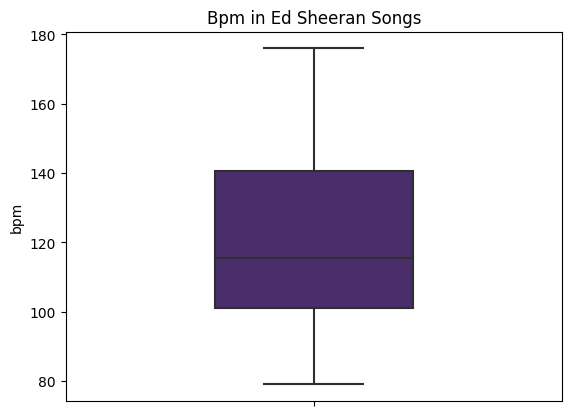

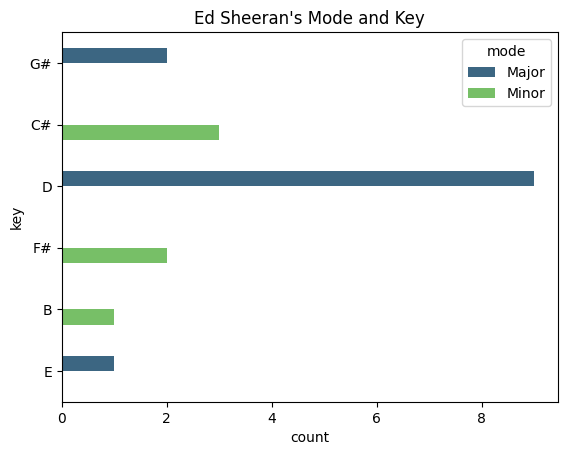

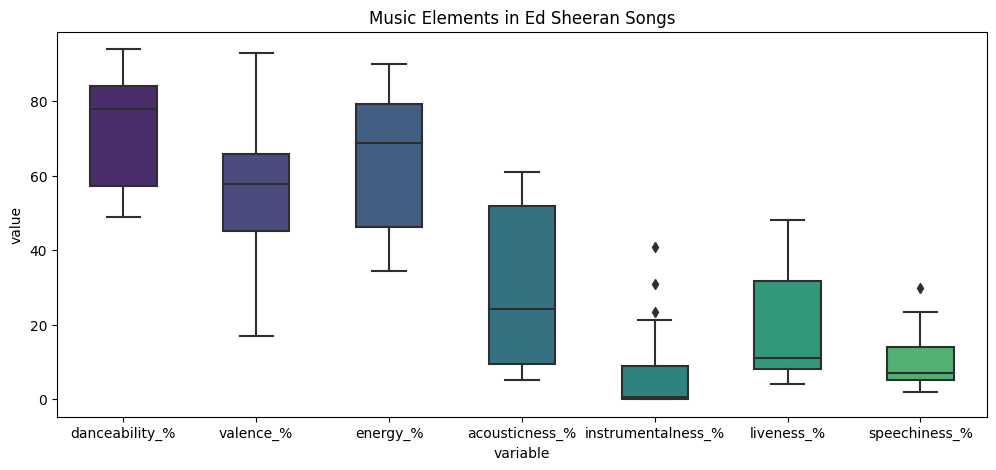

In [88]:
artist_character('Ed Sheeran', top10_ar)

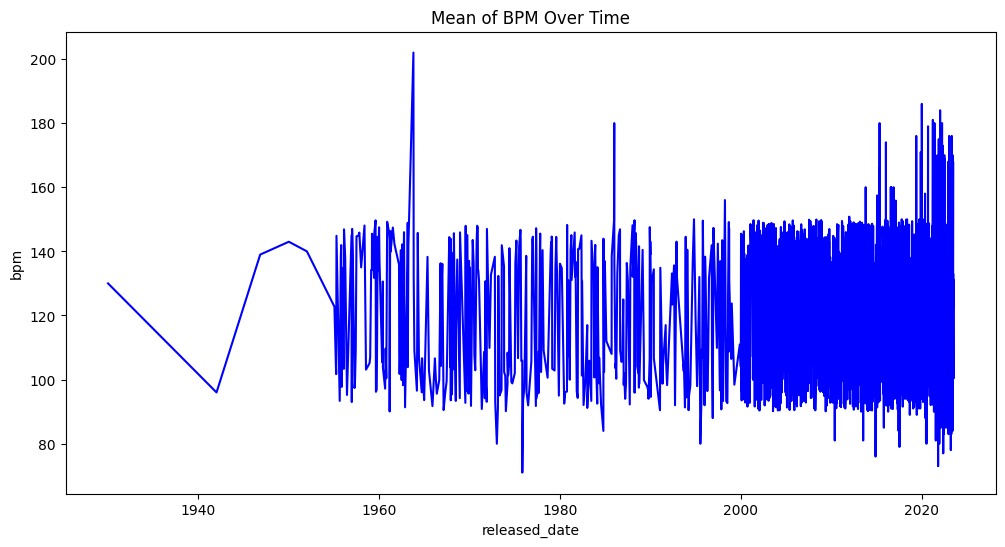

In [89]:
# 1️⃣ Menghitung rata-rata BPM berdasarkan tanggal rilis lagu
bpm_overtime = df.groupby('released_date', as_index=False)['bpm'].mean()

# 2️⃣ Membuat plot garis untuk melihat perubahan BPM seiring waktu
plt.figure(figsize=(12, 6))  # Menentukan ukuran plot
sns.lineplot(data=bpm_overtime, x='released_date', y='bpm', 
             color='blue').set(title='Mean of BPM Over Time')  # Membuat plot garis

# 3️⃣ Menampilkan plot
plt.show()


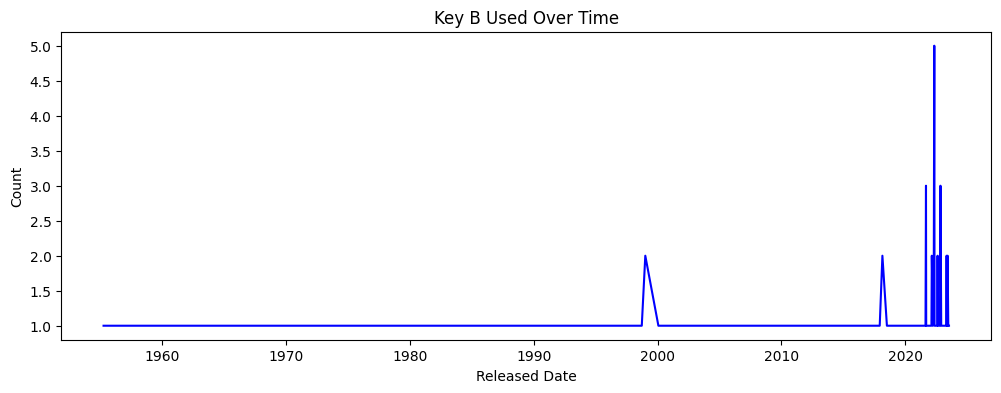

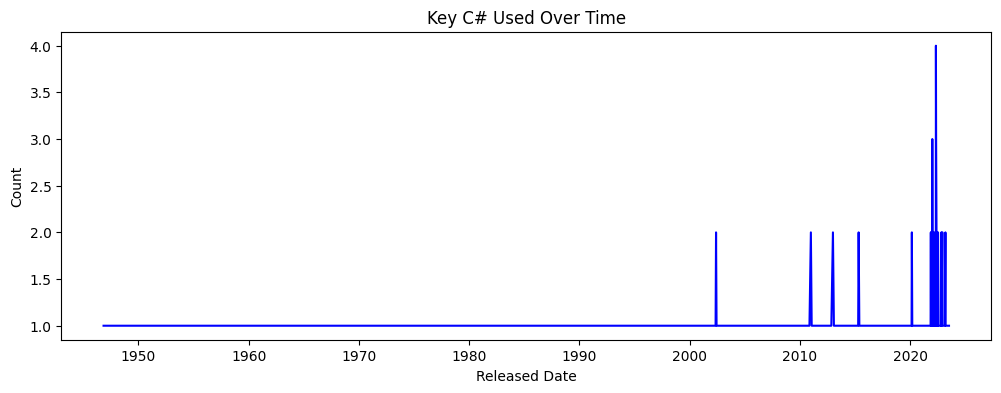

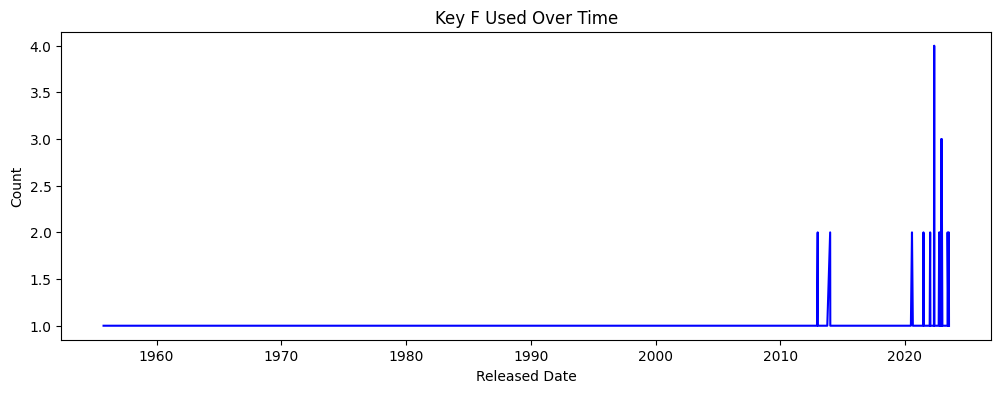

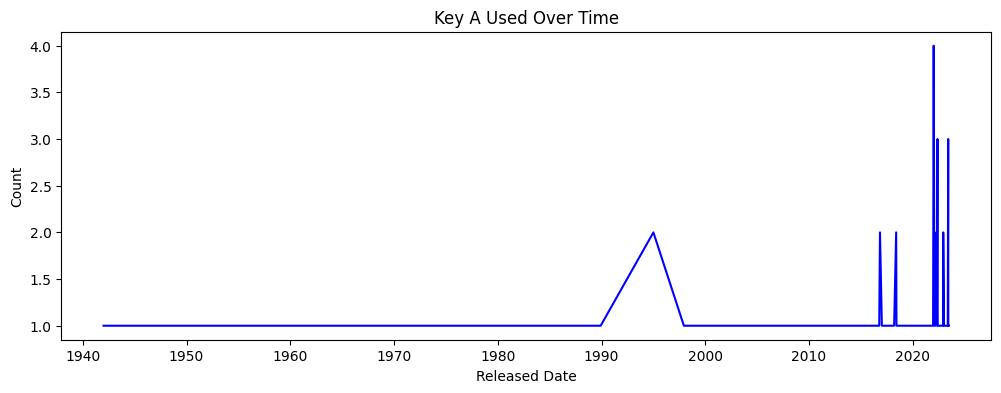

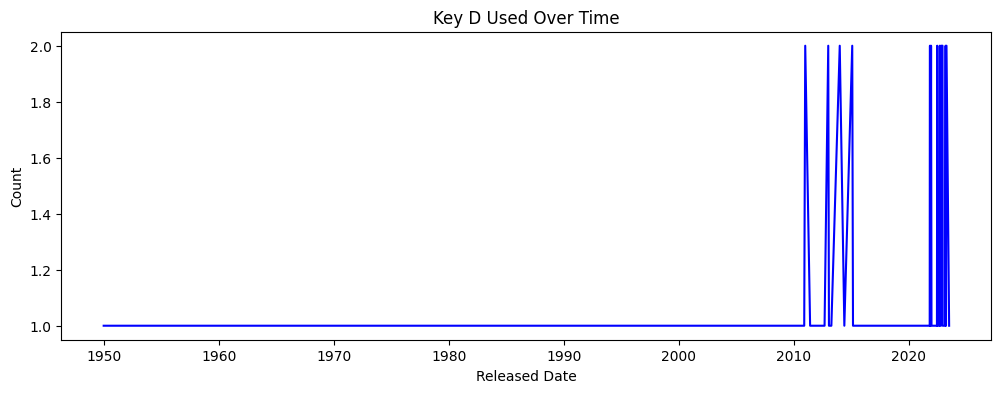

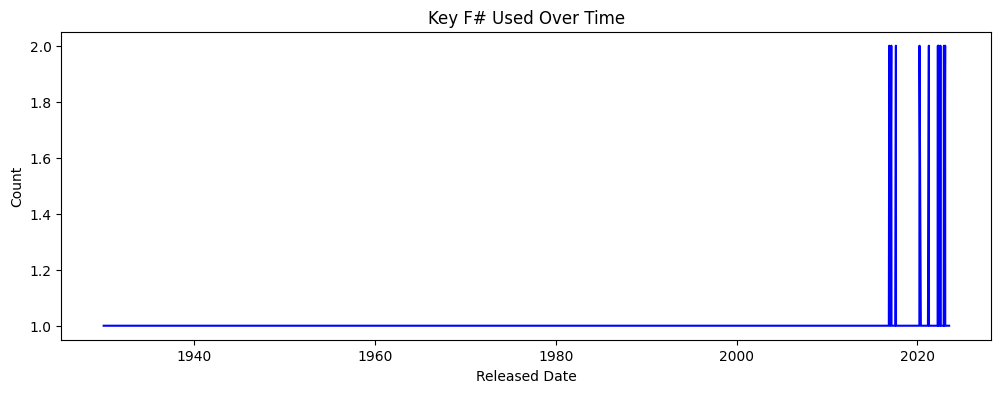

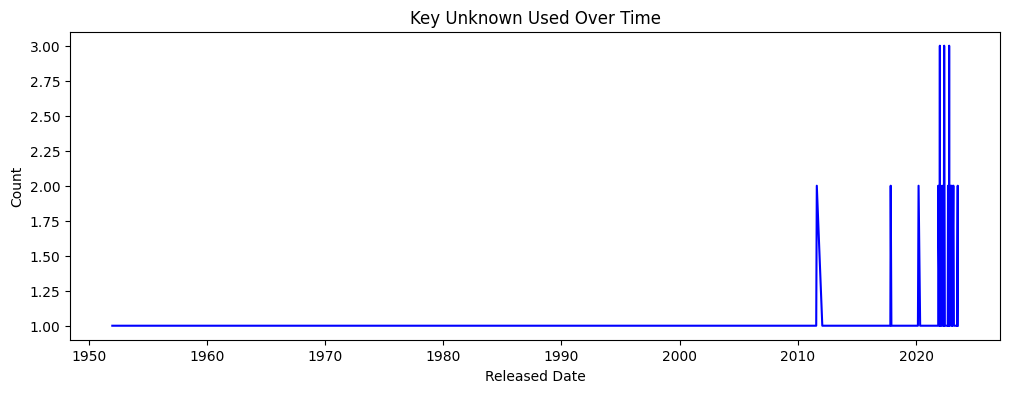

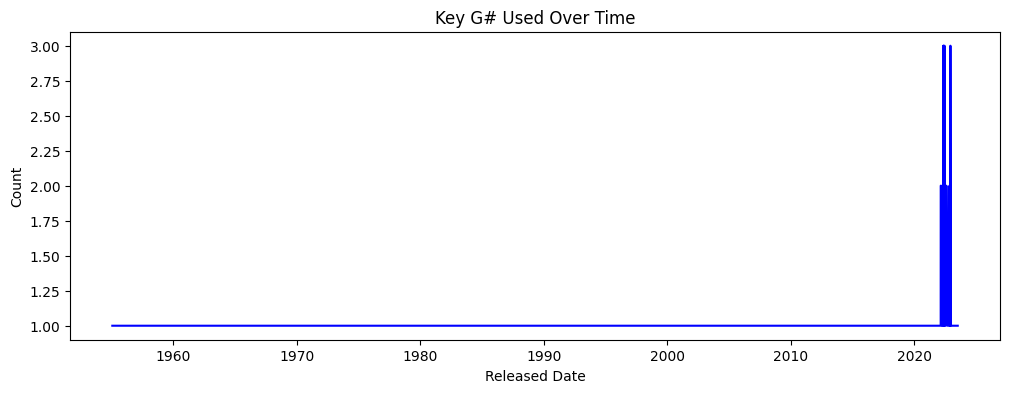

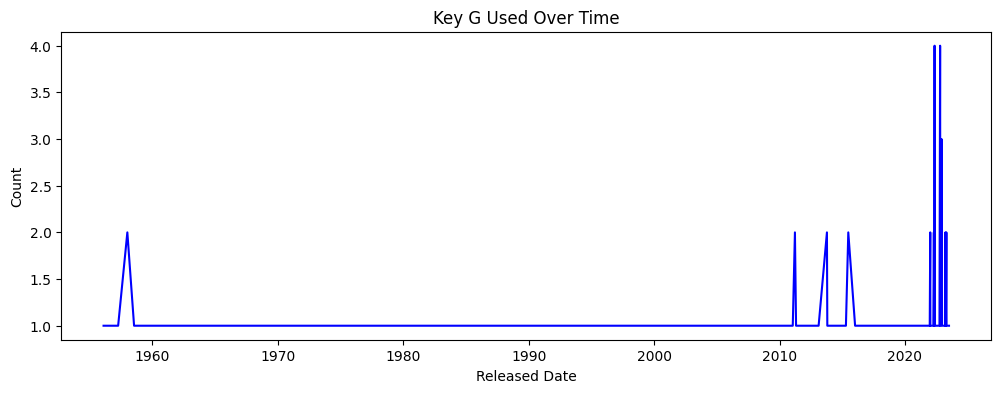

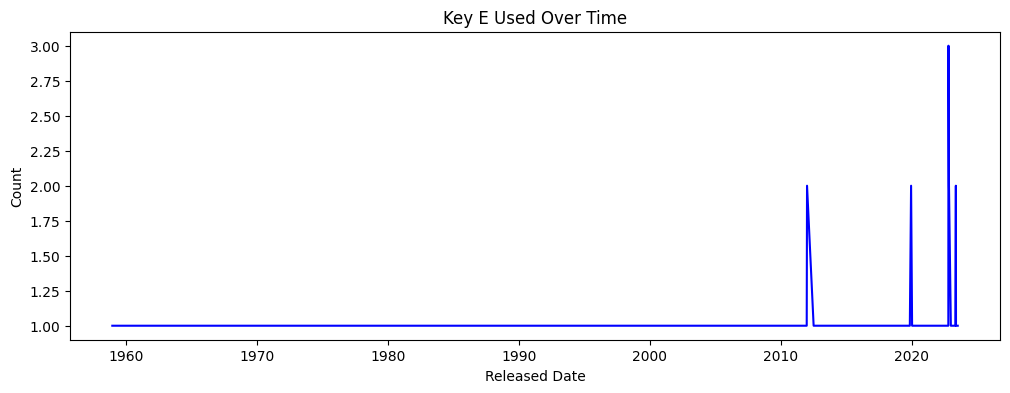

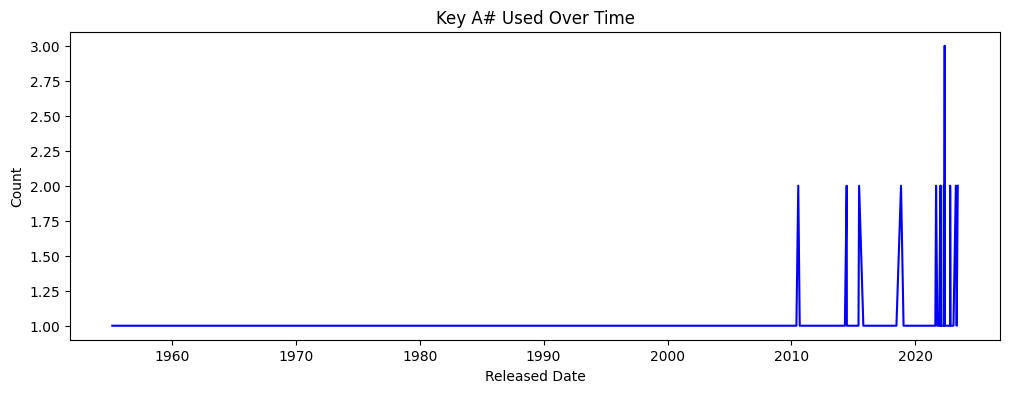

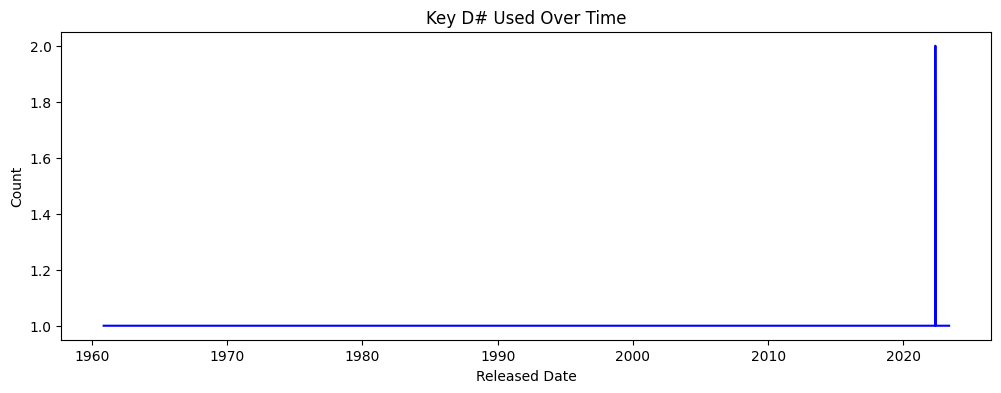

In [90]:
# 1️⃣ Iterasi untuk setiap nada dasar (key) unik dalam kolom 'key'
for key in df['key'].unique():
    fig = plt.figure(figsize=(12, 4))  # Menentukan ukuran plot
    
    # 2️⃣ Memfilter DataFrame berdasarkan key tertentu dan menghitung jumlah kemunculannya seiring waktu
    key_overtime = df[df['key'] == key][['released_date', 'key']].value_counts().reset_index()
    
    # 3️⃣ Mengganti nama kolom yang berisi jumlah lagu dengan nama yang lebih jelas
    key_overtime = key_overtime.rename(columns={0: 'count'})
    
    # 4️⃣ Membuat plot garis untuk menunjukkan perubahan jumlah lagu dengan key tertentu dari waktu ke waktu
    sns.lineplot(data=key_overtime, x='released_date', y='count', color='blue')
    
    # 5️⃣ Menambahkan judul dan label sumbu
    plt.title(f'Key {key} Used Over Time')
    plt.xlabel('Released Date')
    plt.ylabel('Count')
    
    # 6️⃣ Menampilkan plot
    plt.show()


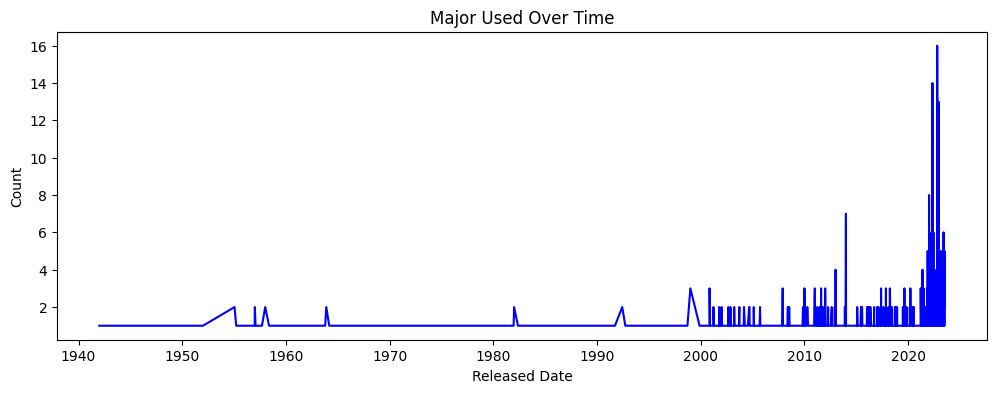

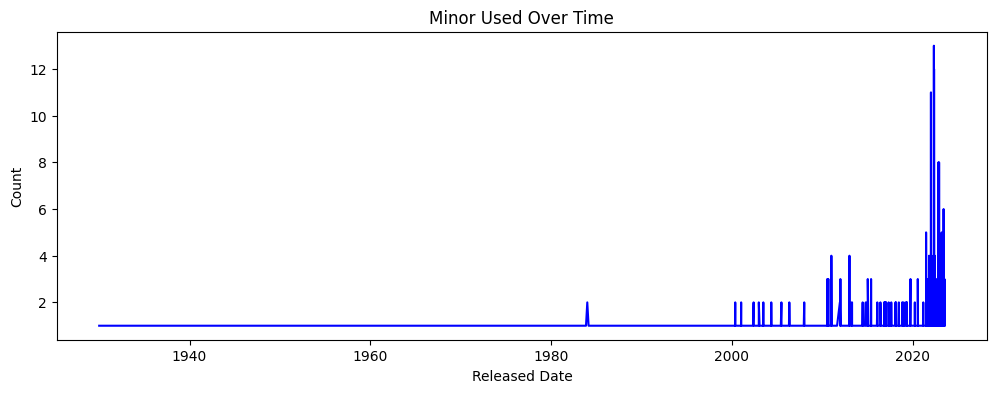

In [91]:
# 1️⃣ Iterasi untuk setiap mode unik dalam kolom 'mode'
for mod in df['mode'].unique():
    fig = plt.figure(figsize=(12, 4))  # Menentukan ukuran plot
    
    # 2️⃣ Memfilter DataFrame berdasarkan mode tertentu dan menghitung jumlah kemunculannya seiring waktu
    mode_overtime = df[df['mode'] == mod][['released_date', 'mode']].value_counts().reset_index()
    
    # 3️⃣ Mengganti nama kolom yang berisi jumlah lagu dengan nama yang lebih jelas
    mode_overtime = mode_overtime.rename(columns={0: 'count'})
    
    # 4️⃣ Membuat plot garis untuk menunjukkan perubahan jumlah lagu dengan mode tertentu dari waktu ke waktu
    sns.lineplot(data=mode_overtime, x='released_date', y='count', color='blue')
    
    # 5️⃣ Menambahkan judul dan label sumbu
    plt.title(f'{mod} Used Over Time')
    plt.xlabel('Released Date')
    plt.ylabel('Count')
    
    # 6️⃣ Menampilkan plot
    plt.show()


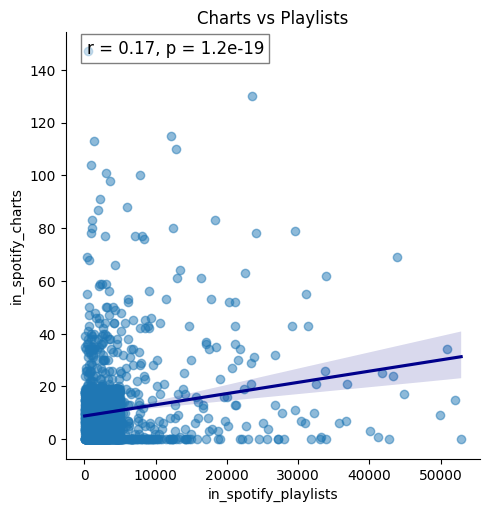

In [92]:
# Membuat scatter plot dengan regresi menggunakan palet viridis
g = sns.lmplot(x='in_spotify_playlists', y='in_spotify_charts', data=df, 
               scatter_kws={'alpha': 0.5}, line_kws={'color': 'darkblue'}, 
               palette='viridis')

# Menambahkan judul plot
g.set(title='Charts vs Playlists')

# Menghitung korelasi Pearson antara playlist dan charts
r, p = pearsonr(df['in_spotify_playlists'], df['in_spotify_charts'])

# Menambahkan teks korelasi di area yang tidak mengganggu
ax = plt.gca()
ax.text(0.05, 0.95, f'r = {r:.2f}, p = {p:.2g}', transform=ax.transAxes, 
        fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Menampilkan plot
plt.show()


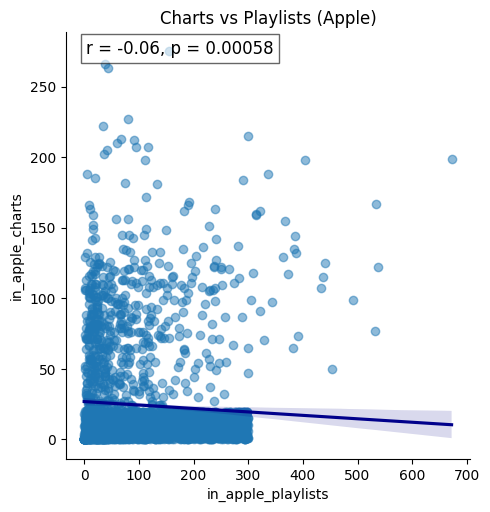

In [93]:
# Membuat scatter plot dengan garis regresi
g = sns.lmplot(x='in_apple_playlists', y='in_apple_charts', data=df, 
               scatter_kws={'alpha': 0.5}, line_kws={'color': 'darkblue'}, 
               palette='viridis')

# Menambahkan judul plot
g.set(title='Charts vs Playlists (Apple)')

# Menghitung korelasi Pearson antara playlist dan charts di Apple Music
r, p = pearsonr(df['in_apple_playlists'], df['in_apple_charts'])

# Menempatkan teks korelasi di lokasi yang rapi
ax = plt.gca()
ax.text(0.05, 0.95, f'r = {r:.2f}, p = {p:.2g}', transform=ax.transAxes, 
        fontsize=12, bbox=dict(facecolor='white', alpha=0.6))

# Menampilkan plot
plt.show()


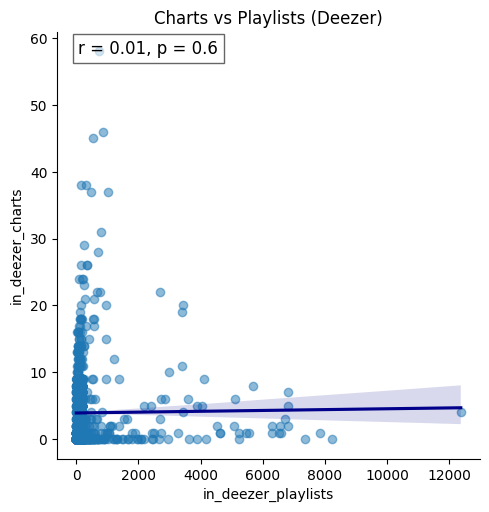

In [94]:
# Membuat scatter plot dengan garis regresi
g = sns.lmplot(x='in_deezer_playlists', y='in_deezer_charts', data=df, 
               scatter_kws={'alpha': 0.5}, line_kws={'color': 'darkblue'}, 
               palette='viridis')

# Menambahkan judul plot
g.set(title='Charts vs Playlists (Deezer)')

# Menghitung korelasi Pearson antara playlist dan charts di Deezer
r, p = pearsonr(df['in_deezer_playlists'], df['in_deezer_charts'])

# Menempatkan teks korelasi dengan background agar lebih jelas
ax = plt.gca()
ax.text(0.05, 0.95, f'r = {r:.2f}, p = {p:.2g}', transform=ax.transAxes, 
        fontsize=12, bbox=dict(facecolor='white', alpha=0.6))

# Menampilkan plot
plt.show()


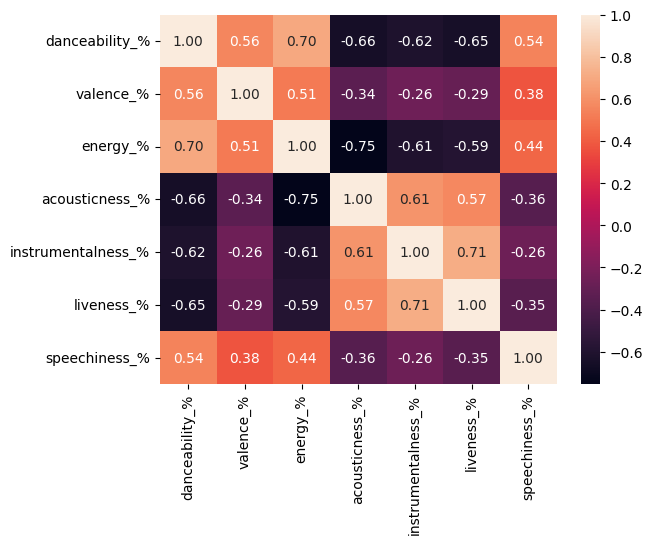

In [95]:
# 📊 Membuat heatmap untuk menampilkan korelasi antar fitur audio
sns.heatmap(df.iloc[:, 17:24].corr(), annot=True, fmt=".2f")

# 🖼️ Menampilkan heatmap
plt.show()


In [96]:
# Membuat DataFrame baru dengan variabel yang dipilih
d2 = df[['bpm', 'key', 'mode', 'danceability_%', 'valence_%', 'energy_%', 
         'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']]

# Melakukan one-hot encoding pada kolom 'key' berdasarkan urutan nada
oe = OneHotEncoder()
key_oe = oe.fit(np.array(['A', 'A#', 'B', 'C#', 'D', 'D#', 'E', 'F', 
                          'F#', 'G', 'G#', 'Unknown']).reshape(-1, 1))
key_encoded = key_oe.transform(np.array(d2['key']).reshape(-1, 1)).toarray()

# Melakukan one-hot encoding pada kolom 'mode' 
mode_oe = oe.fit(np.array(['Major', 'Minor']).reshape(-1, 1))
mode_encoded = mode_oe.transform(np.array(d2['mode']).reshape(-1, 1)).toarray()

# Mengubah hasil encoding ke dalam DataFrame dengan nama kolom yang sesuai
key_new = pd.DataFrame(key_encoded).rename(columns={0:'A', 1:'A#', 2:'B', 3:'C#', 4:'D', 5:'D#', 
                                                    6:'E', 7:'F', 8:'F#', 9:'G', 10:'G#', 11:'Unknown'})
mode_new = pd.DataFrame(mode_encoded).rename(columns={0:'Major', 1:'Minor'})

# Menggabungkan semua variabel ke dalam satu DataFrame baru
X = pd.concat([d2['bpm'], key_new, mode_new, d2.iloc[:, 4:]], axis=1)

# Normalisasi kolom 'bpm' dan fitur audio lainnya menggunakan MinMaxScaler
bpm_scale = MinMaxScaler().fit(X[['bpm']])
X['bpm'] = bpm_scale.transform(X[['bpm']])

# Normalisasi fitur audio lainnya
for i in X.iloc[:, 15:]:
    af_scale = MinMaxScaler().fit(X[[i]])
    X[i] = af_scale.transform(X[[i]])


In [97]:
X.head()

,bpm,A,A#,B,C#,D,D#,E,F,F#,G,G#,Unknown,Major,Minor,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,0.425532,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.913978,0.840909,0.319588,0.000000,0.053191,0.032258
1,0.191489,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.612903,0.738636,0.072165,0.000000,0.074468,0.032258
2,0.517730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.301075,0.500000,0.175258,0.000000,0.297872,0.064516
3,0.744681,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.580645,0.715909,0.113402,0.000000,0.085106,0.209677
4,0.560284,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.204301,0.806818,0.144330,0.692308,0.085106,0.064516


In [98]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bpm                 2859 non-null   float64
 1   A                   2859 non-null   float64
 2   A#                  2859 non-null   float64
 3   B                   2859 non-null   float64
 4   C#                  2859 non-null   float64
 5   D                   2859 non-null   float64
 6   D#                  2859 non-null   float64
 7   E                   2859 non-null   float64
 8   F                   2859 non-null   float64
 9   F#                  2859 non-null   float64
 10  G                   2859 non-null   float64
 11  G#                  2859 non-null   float64
 12  Unknown             2859 non-null   float64
 13  Major               2859 non-null   float64
 14  Minor               2859 non-null   float64
 15  valence_%           2859 non-null   float64
 16  energy

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

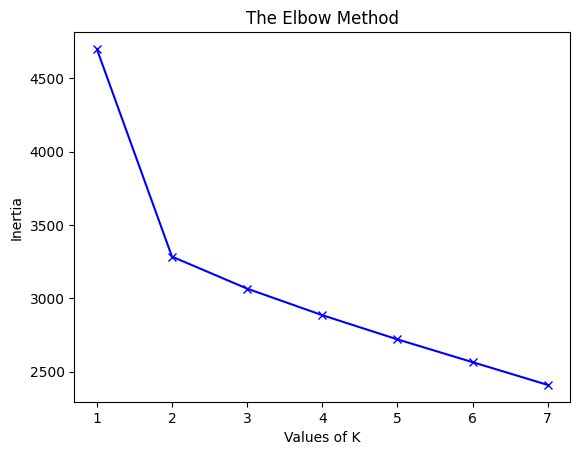

In [99]:
# Menggunakan metode Elbow untuk menentukan jumlah klaster optimal

# Menyimpan nilai inertia untuk setiap jumlah klaster
inertia = []
mapping = {}

# Rentang nilai K yang akan diuji
K = range(1, 8)

# Iterasi untuk setiap nilai K
for k in K:
    # Membangun dan melatih model K-Means dengan jumlah klaster k
    kmeanModel = KMeans(n_clusters=k).fit(X)
    kmeanModel.fit(X)
    
    # Menyimpan nilai inertia untuk jumlah klaster k
    inertia.append(kmeanModel.inertia_)
    mapping[k] = kmeanModel.inertia_

# Memvisualisasikan metode Elbow dengan plot
plt.plot(K, inertia, 'bx-', color='blue')  # Plot nilai inertia terhadap jumlah klaster
plt.xlabel('Values of K')  # Label sumbu X
plt.ylabel('Inertia')  # Label sumbu Y
plt.title('The Elbow Method')  # Judul grafik
plt.show()  # Menampilkan grafik


In [100]:
# Pipeline untuk melakukan reduksi dimensi menggunakan PCA dengan 2 komponen utama
preprocessor = Pipeline([
    ("pca", PCA(n_components=2)),  # Mengurangi dimensi data menjadi 2 menggunakan PCA
])

# Pipeline untuk K-Means clustering dengan 2 klaster
clusterer = Pipeline([
    ("kmeans", KMeans(n_clusters=2, init="k-means++", n_init=50, max_iter=500)),  # Inisialisasi K-Means dengan k=2
])

# Menggabungkan kedua pipeline menjadi satu
pipe = Pipeline([
    ("preprocessor", preprocessor),  # Pertama, lakukan reduksi dimensi dengan PCA
    ("clusterer", clusterer)         # Kemudian, lakukan clustering dengan K-Means
])

# Menyesuaikan pipeline dengan data
pipe.fit(X)  # Melatih pipeline dengan dataset X


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('pca', PCA(n_components=2))])),
                ('clusterer',
                 Pipeline(steps=[('kmeans',
                                  KMeans(max_iter=500, n_clusters=2,
                                         n_init=50))]))])

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

In [101]:
#Type your code here

pcadf_selectedd = pd.DataFrame(
    pipe["preprocessor"].transform(X),
    columns=["component_1", "component_2"]
)
pcadf_selectedd["predicted_cluster"] = pipe["clusterer"]["kmeans"].labels_

# Evaluate the model using silhoutte score
preprocessed_data = pipe["preprocessor"].transform(X)
predicted_labels = pipe["clusterer"]["kmeans"].labels_ 
print(f"Silhoutte score : {silhouette_score(preprocessed_data, predicted_labels)}")

Silhoutte score : 0.711503041352139


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [102]:
# Feature Selection
selector = SelectKBest(score_func=f_classif, k=10)  # Pilih 10 fitur terbaik
X_selected = selector.fit_transform(X, pipe["clusterer"]["kmeans"].labels_)

# Training ulang dengan fitur yang dipilih
pipe_selected = Pipeline([
    ("preprocessor", PCA(n_components=2)),  # Gunakan PCA dengan 2 komponen
    ("clusterer", KMeans(n_clusters=2, init="k-means++", n_init=50, max_iter=500))
])

pipe_selected.fit(X_selected)

# Evaluasi Silhouette Score setelah Feature Selection
preprocessed_data_selected = pipe_selected["preprocessor"].transform(X_selected)
predicted_labels_selected = pipe_selected.named_steps["clusterer"].labels_
silhouette_selected = silhouette_score(preprocessed_data_selected, predicted_labels_selected)



print(f"Silhouette Score SEBELUM Feature Selection: {silhouette_score(preprocessed_data, predicted_labels):.4f}")
print(f"Silhouette Score SESUDAH Feature Selection (SelectKBest): {silhouette_selected:.4f}")


Silhouette Score SEBELUM Feature Selection: 0.7115
Silhouette Score SESUDAH Feature Selection (SelectKBest): 0.8172


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

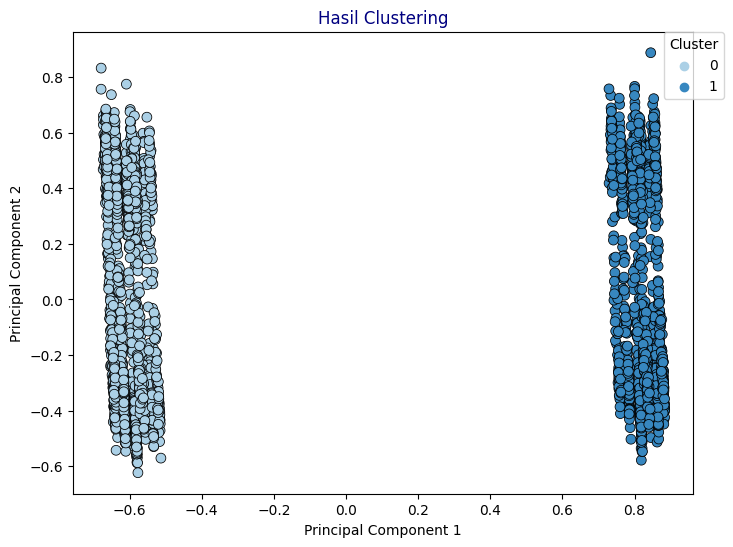

In [103]:
# Membuat DataFrame hasil  CLustering
# Membuat DataFrame hasil Clustering setelah Feature Selection
pcadf_selected = pd.DataFrame(
    pipe_selected["preprocessor"].transform(X_selected),
    columns=["component_1", "component_2"]
)
pcadf_selected["predicted_cluster"] = pipe_selected["clusterer"].labels_


# Membuat plot scatter hasil CLustering
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="component_1", y="component_2", data=pcadf_selectedd, 
    hue="predicted_cluster", palette="Blues", s=50, edgecolor="black"
)
plt.title("Hasil Clustering", fontsize=12, color="navy")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), borderaxespad=0.0)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Menampilkan plot
plt.show()


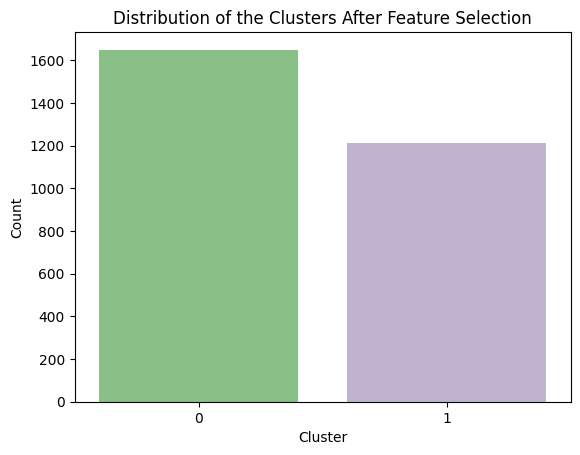

In [104]:
# Membuat countplot untuk distribusi cluster setelah Feature Selection
fig = sns.countplot(x=pcadf_selected["predicted_cluster"], palette="Accent")
fig.set_title("Distribution of the Clusters After Feature Selection")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   track_name            2859 non-null   object        
 1   artist(s)_name        2859 non-null   object        
 2   artist_count          2859 non-null   int64         
 3   released_year         2859 non-null   int64         
 4   released_month        2859 non-null   int64         
 5   released_day          2859 non-null   int64         
 6   in_spotify_playlists  2859 non-null   int64         
 7   in_spotify_charts     2859 non-null   int64         
 8   streams               2859 non-null   int64         
 9   in_apple_playlists    2859 non-null   int64         
 10  in_apple_charts       2859 non-null   int64         
 11  in_deezer_playlists   2859 non-null   int64         
 12  in_deezer_charts      2859 non-null   int64         
 13  in_shazam_charts  

In [106]:
# Type your code here
df["cluster"] = pipe["clusterer"]["kmeans"].labels_


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [107]:
# Type your code here

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

📊 Ringkasan Statistik Tiap Cluster:

cluster                        0            1
artist_count  count  1649.000000  1210.000000
              mean      2.463918     2.598347
              std       1.450248     1.443389
              min       1.000000     1.000000
              25%       1.000000     1.000000
...                          ...          ...
speechiness_% min       2.000000     3.000000
              25%       6.639120     7.480797
              50%      12.295747    12.884352
              75%      20.439867    21.282944
              max      59.000000    64.000000

[160 rows x 2 columns]

📌 Data dalam tiap cluster:

🔹 Cluster 0:
                            track_name     artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)   Latto, Jung Kook             2   
1                                 LALA        Myke Towers             1   
2                              vampire     Olivia Rodrigo             1   
3                         Cruel Summer       

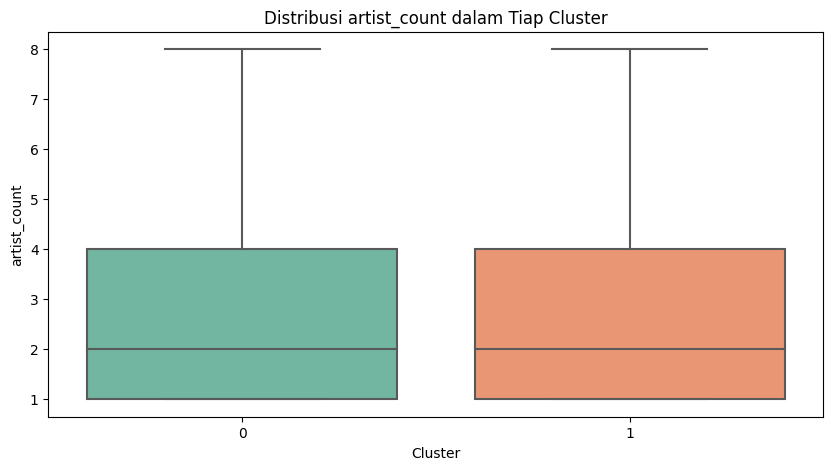

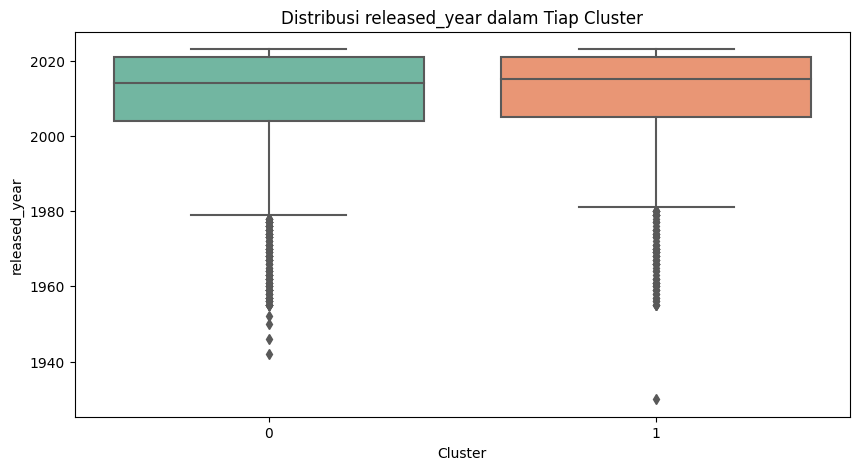

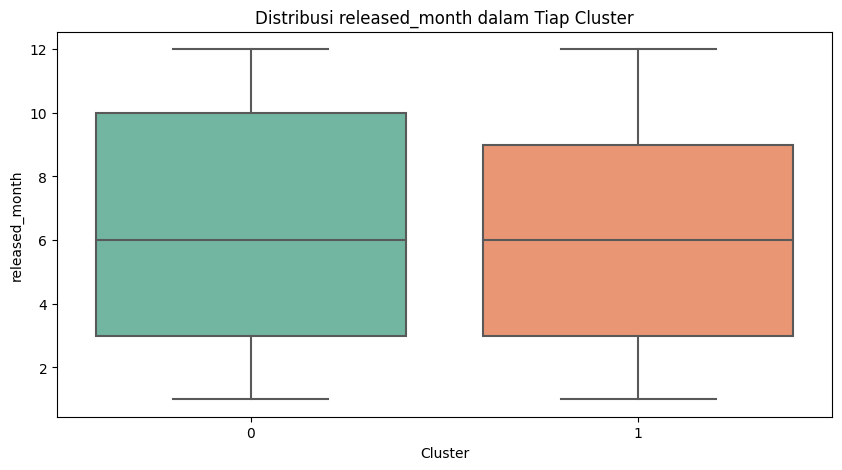

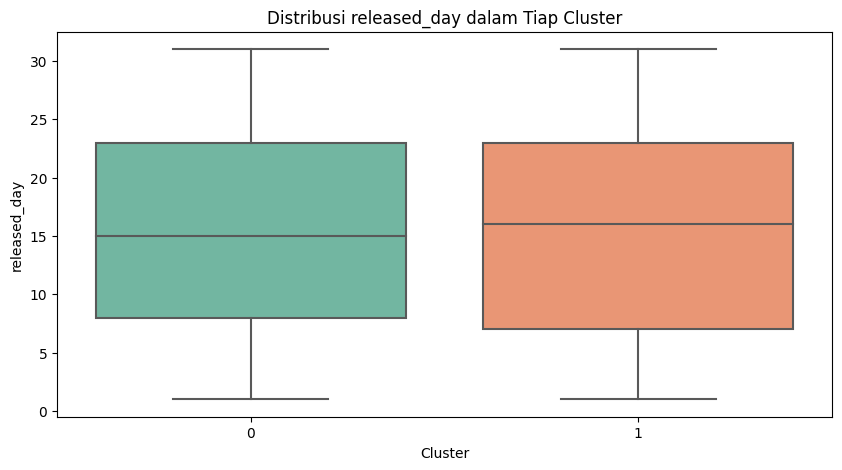

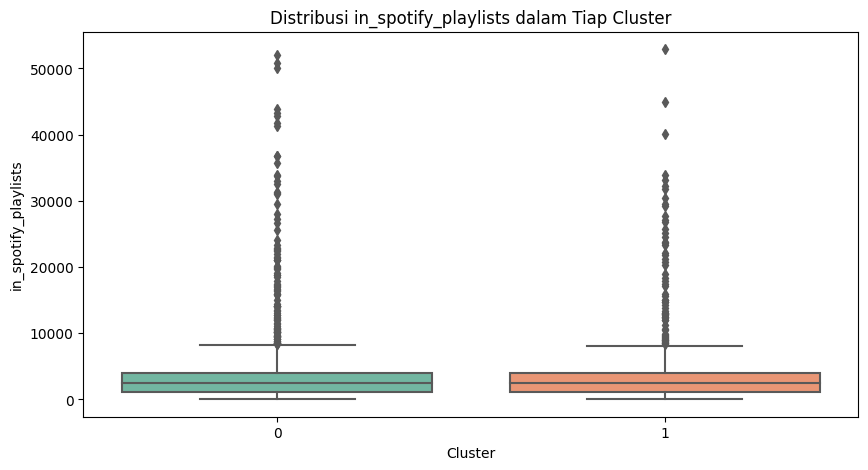

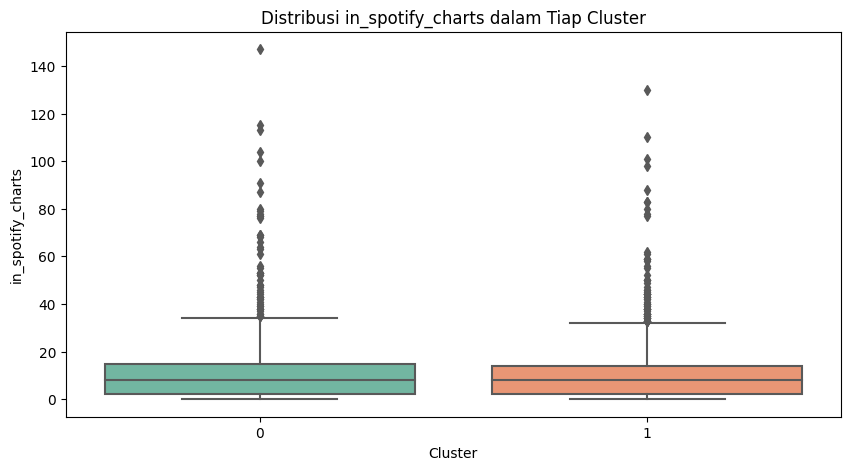

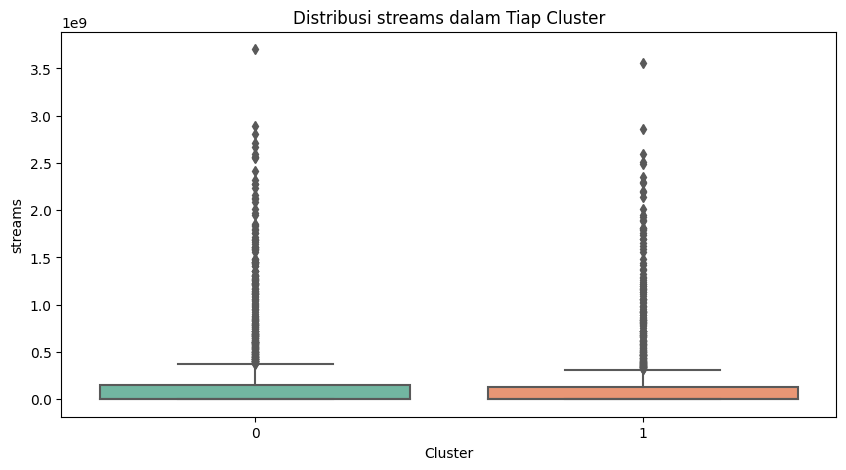

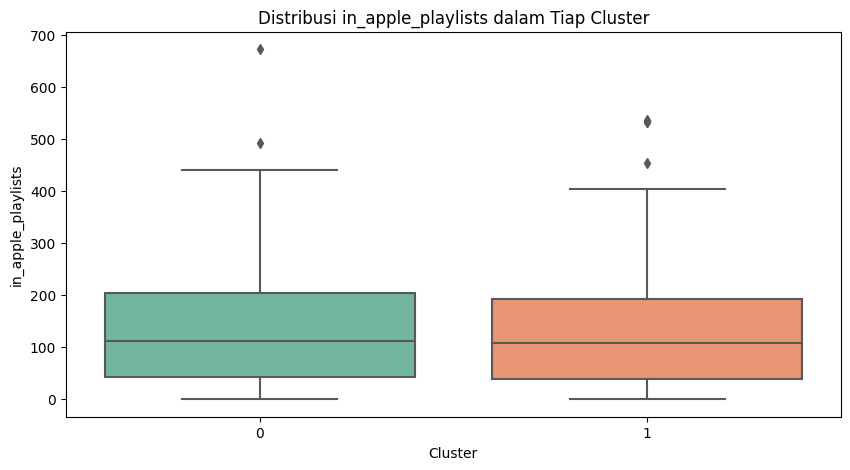

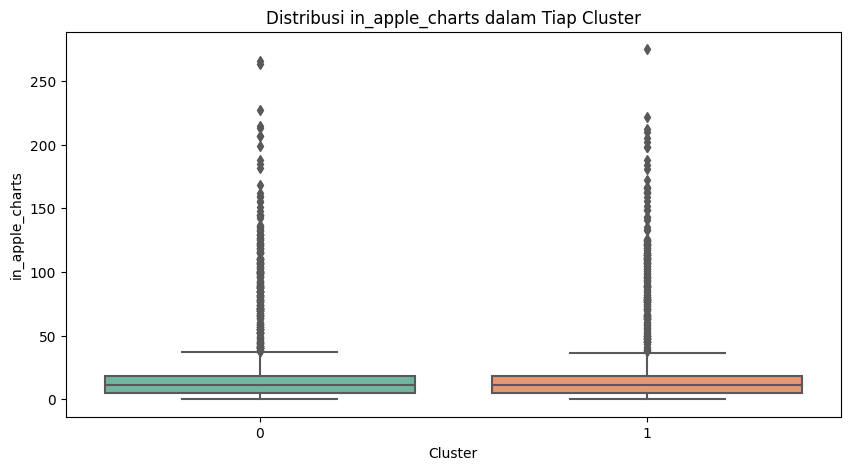

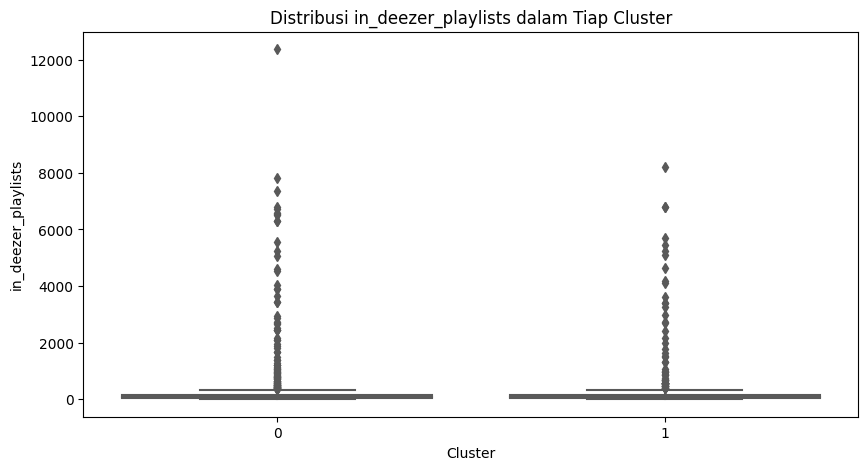

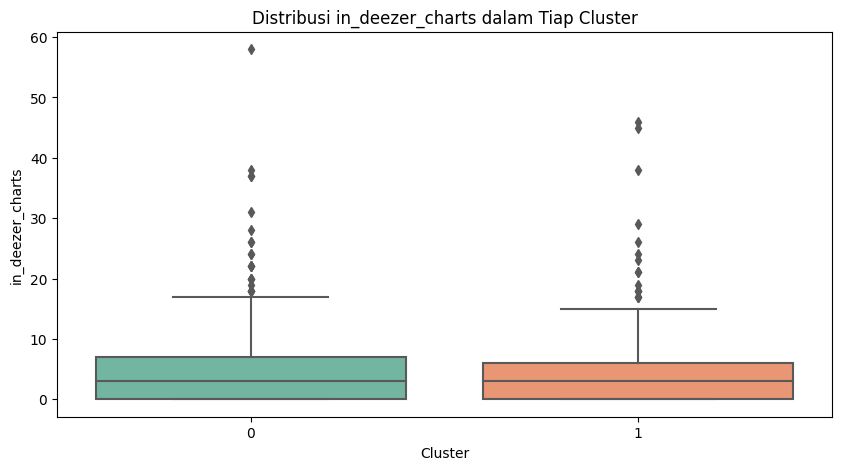

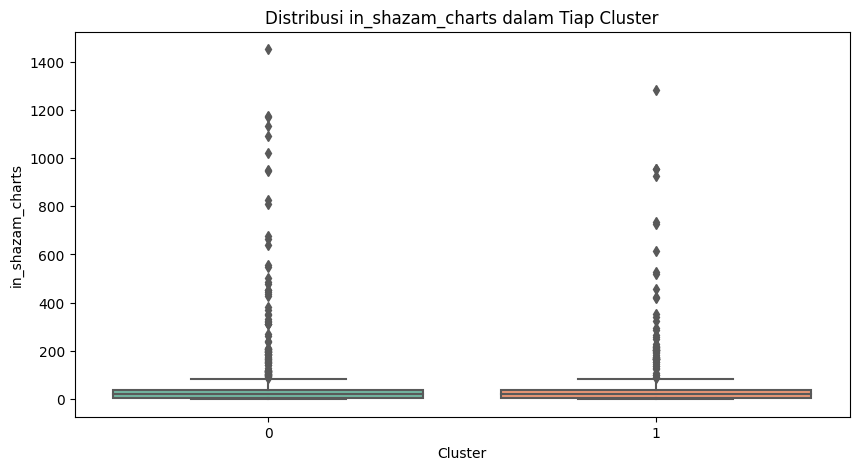

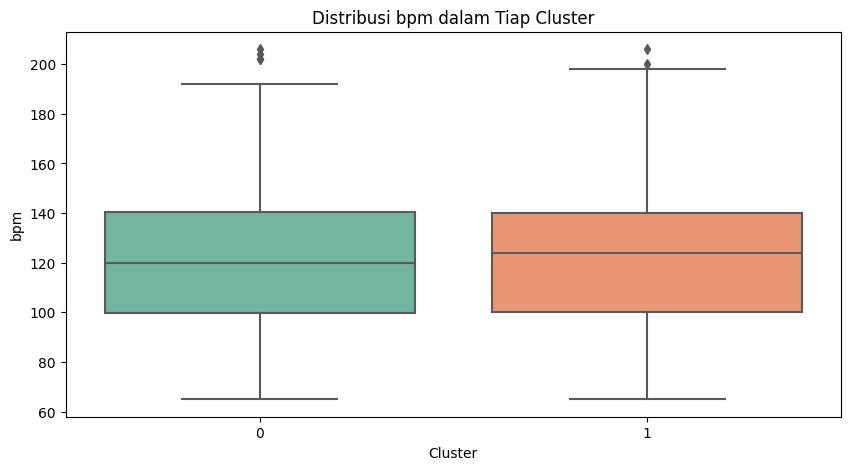

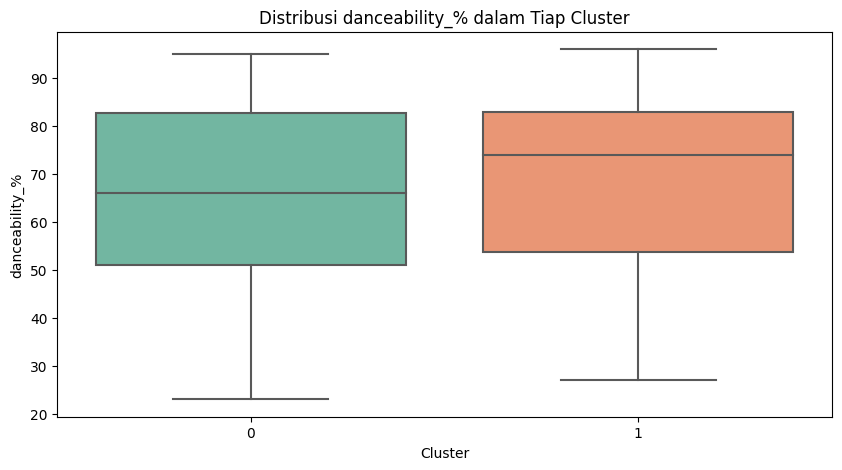

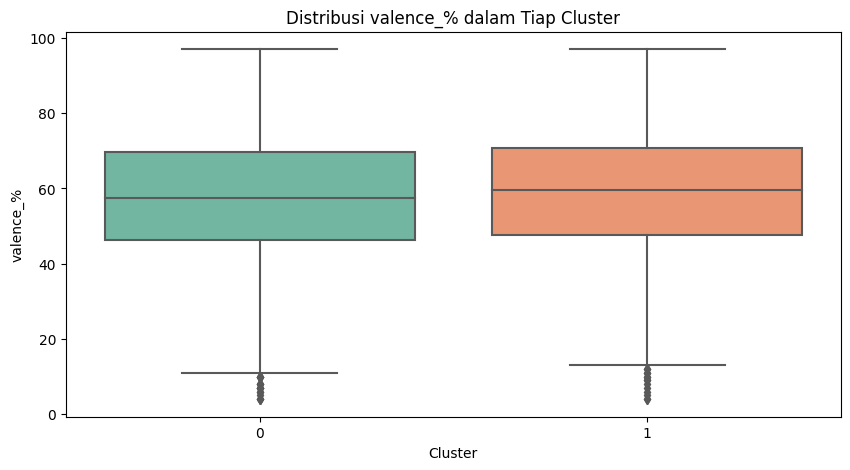

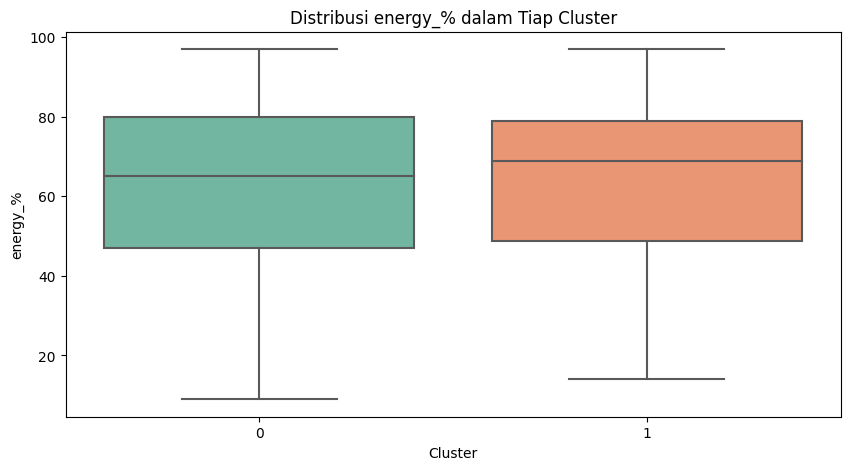

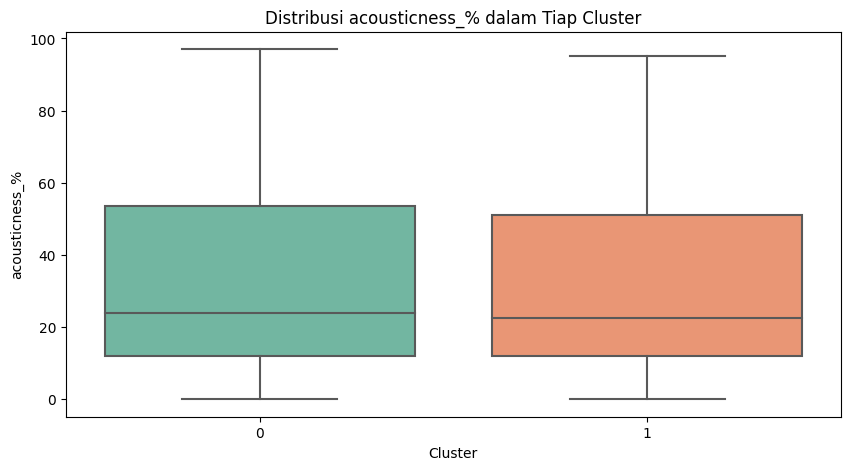

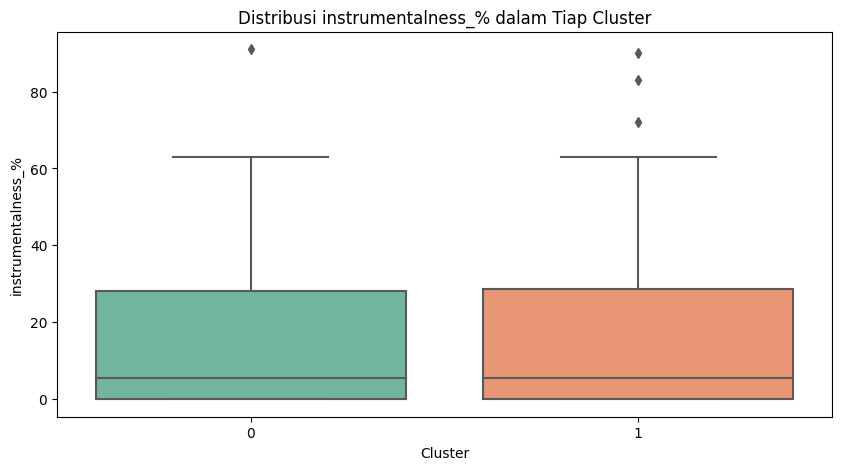

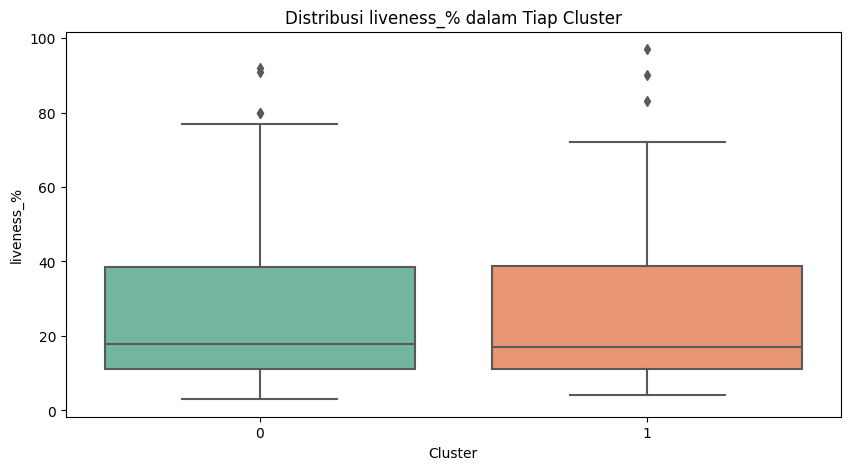

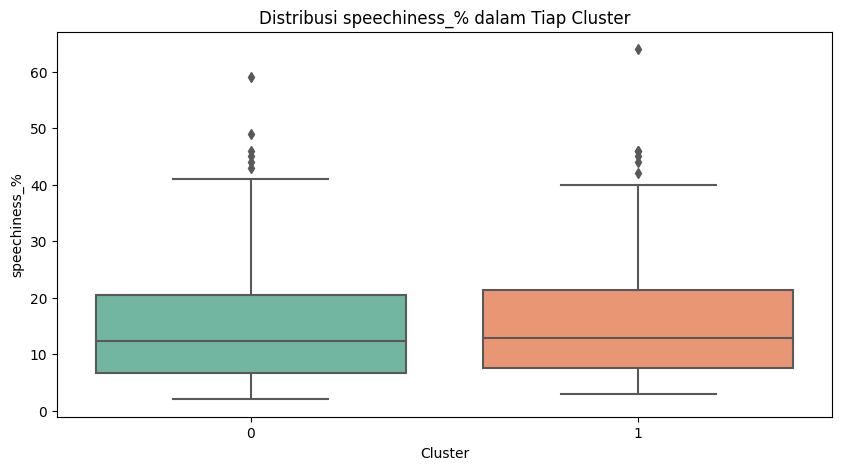

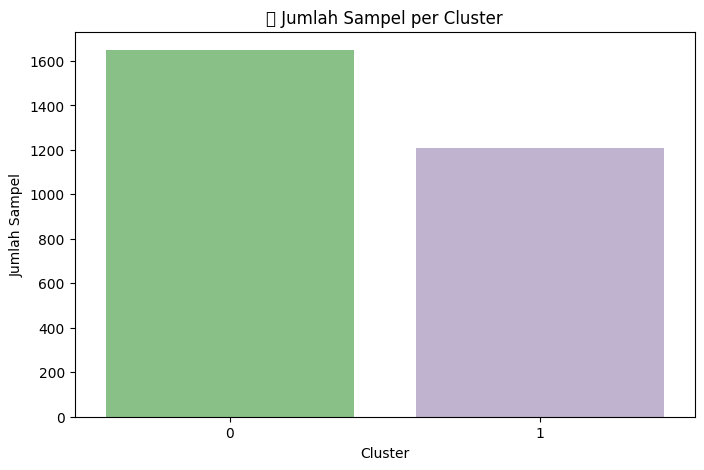


📊 Jumlah Sampel per Cluster:

0    1649
1    1210
Name: cluster, dtype: int64


In [108]:
# Pastikan df sudah memiliki kolom 'cluster'
def analyze_clusters(df):
    if 'cluster' not in df.columns:
        raise ValueError("DataFrame harus memiliki kolom 'cluster'")
    
    # Menampilkan ringkasan statistik untuk setiap cluster
    print("📊 Ringkasan Statistik Tiap Cluster:\n")
    cluster_summary = df.groupby("cluster").describe().T
    print(cluster_summary)
    
    # Menampilkan data-data dalam tiap cluster
    print("\n📌 Data dalam tiap cluster:\n")
    for cluster in sorted(df['cluster'].unique()):
        print(f"🔹 Cluster {cluster}:")
        print(df[df['cluster'] == cluster].head(5))  # Menampilkan 5 data pertama untuk ringkas
        print("\n---\n")
    
    # Visualisasi distribusi fitur dalam setiap cluster
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    numeric_cols.remove('cluster')  # Hindari clustering column
    
    for col in numeric_cols:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=df['cluster'], y=df[col], palette="Set2")
        plt.title(f'Distribusi {col} dalam Tiap Cluster')
        plt.xlabel('Cluster')
        plt.ylabel(col)
        plt.show()

    # Visualisasi jumlah sampel per cluster
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df["cluster"], palette="Accent")
    plt.title("🔢 Jumlah Sampel per Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Jumlah Sampel")
    plt.show()
    
    print("\n📊 Jumlah Sampel per Cluster:\n")
    print(df["cluster"].value_counts())
    
    return cluster_summary

# Contoh penggunaan
cluster_summary = analyze_clusters(df)


In [109]:
# Menghitung rata-rata (mean) untuk setiap fitur dalam masing-masing cluster
cluster_mean = df.groupby("cluster").mean()

# Menampilkan hasil
print(cluster_mean)


         artist_count  released_year  released_month  released_day  \
cluster                                                              
0            2.463918    2008.788963        6.446331     15.336568   
1            2.598347    2010.381818        6.249587     15.328926   

         in_spotify_playlists  in_spotify_charts       streams  \
cluster                                                          
0                 3534.560946          10.040024  1.781278e+08   
1                 3277.490909          10.526446  1.619138e+08   

         in_apple_playlists  in_apple_charts  in_deezer_playlists  \
cluster                                                             
0                128.084294        23.254093           208.528805   
1                122.832231        24.074380           182.603306   

         in_deezer_charts  in_shazam_charts         bpm  danceability_%  \
cluster                                                                   
0                3.932686  

# **Rata-rata Fitur dalam Tiap Cluster**

Berdasarkan hasil clustering, berikut adalah rata-rata nilai dari setiap fitur dalam masing-masing cluster:

| **Fitur**               | **Cluster 0** | **Cluster 1** |
|-------------------------|--------------|--------------|
| **Artist Count**        | 2.46         | 2.60         |
| **Tahun Rilis**        | 2008.79      | 2010.38      |
| **Bulan Rilis**        | 6.45         | 6.25         |
| **Tanggal Rilis**      | 15.34        | 15.33        |
| **In Spotify Playlists** | 3534.56      | 3277.49      |
| **In Spotify Charts**  | 10.04        | 10.53        |
| **Total Streams**      | 178.13 juta  | 161.91 juta  |
| **In Apple Playlists** | 128.08       | 122.83       |
| **In Apple Charts**    | 23.25        | 24.07        |
| **In Deezer Playlists** | 208.53      | 182.60       |
| **In Deezer Charts**   | 3.93         | 3.93         |
| **In Shazam Charts**   | 37.02        | 33.32        |
| **BPM (Tempo)**        | 121.02       | 121.38       |
| **Danceability (%)**   | 66.79%       | 68.83%       |
| **Valence (%)**        | 56.72%       | 58.34%       |
| **Energy (%)**         | 63.10%       | 64.05%       |
| **Acousticness (%)**   | 32.90%       | 30.96%       |
| **Instrumentalness (%)** | 13.79%     | 13.70%       |
| **Liveness (%)**       | 24.91%       | 24.68%       |
| **Speechiness (%)**    | 13.96%       | 14.84%       |

## **Analisis Cluster**
### **Cluster 0** 🎵
- Berisi lagu-lagu dengan rata-rata tahun rilis lebih **lama** (**2008**), menunjukkan dominasi lagu-lagu yang lebih **klasik**.
- Rata-rata **jumlah streaming lebih tinggi** dibanding Cluster 1.
- **Danceability, energy, dan valence** sedikit lebih rendah dibanding Cluster 1, menandakan lagu-lagu dalam cluster ini cenderung lebih **kalem atau santai**.
- Memiliki nilai **acousticness lebih tinggi**, yang menunjukkan lebih banyak lagu dengan elemen **akustik**.

### **Cluster 1** 🎶
- Berisi lagu-lagu dengan rata-rata tahun rilis **lebih baru** (**2010**).
- Memiliki **danceability dan valence lebih tinggi**, yang berarti lagu-lagu di cluster ini cenderung **lebih ceria dan mudah untuk menari**.
- **Energy sedikit lebih tinggi**, menandakan lagu-lagu di cluster ini lebih **bersemangat** dibanding Cluster 0.
- **Speechiness lebih tinggi**, menunjukkan kemungkinan adanya lebih banyak lagu dengan lirik yang dominan, seperti **rap atau spoken words**.

## **Kesimpulan**
- **Cluster 0** terdiri dari lagu-lagu **lebih lama dan lebih santai**, dengan sedikit lebih banyak elemen **akustik**.
- **Cluster 1** memiliki lagu-lagu **lebih baru, lebih enerjik, dan lebih ceria**, dengan karakteristik **lebih cocok untuk menari**.

Hasil clustering ini dapat digunakan untuk memahami perbedaan karakteristik lagu berdasarkan perilaku streaming dan elemen musiknya. 🚀🎧


# Contoh interpretasi [TEMPLATE]
# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 1:
- **Rata-rata Annual Income (k$):** 48,260  
- **Rata-rata Spending Score (1-100):** 56.48  
- **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan menengah dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang moderat dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka.

## Cluster 2:
- **Rata-rata Annual Income (k$):** 86,540  
- **Rata-rata Spending Score (1-100):** 82.13  
- **Analisis:** Cluster ini menunjukkan pelanggan dengan pendapatan tahunan tinggi dan pengeluaran yang sangat tinggi. Pelanggan di cluster ini merupakan kelompok premium dengan daya beli yang kuat dan cenderung mengeluarkan uang dalam jumlah besar untuk produk atau layanan.

## Cluster 3:
- **Rata-rata Annual Income (k$):** 87,000  
- **Rata-rata Spending Score (1-100):** 18.63  
- **Analisis:** Cluster ini terdiri dari pelanggan dengan pendapatan tahunan yang tinggi tetapi pengeluaran yang rendah. Mereka mungkin memiliki kapasitas finansial yang baik namun tidak terlalu aktif dalam berbelanja. Ini bisa menunjukkan bahwa mereka lebih selektif dalam pengeluaran mereka atau mungkin lebih cenderung untuk menyimpan uang.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [110]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,released_date,cluster
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125.0,B,Major,80.0,89.0,83.0,31.0,0.0,8.0,4.0,2023-07-14,0
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92.0,C#,Major,71.0,61.0,74.0,7.0,0.0,10.0,4.0,2023-03-23,0
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138.0,F,Major,51.0,32.0,53.0,17.0,0.0,31.0,6.0,2023-06-30,0
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170.0,A,Major,55.0,58.0,72.0,11.0,0.0,11.0,15.0,2019-08-23,0
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144.0,A,Minor,65.0,23.0,80.0,14.0,63.0,11.0,6.0,2023-05-18,1


In [111]:
# Simpan ke CSV

df.to_csv("Dataset_clustering.csv", index=False)

print("File Dataset_clustering.csv berhasil disimpan!")

File Dataset_clustering.csv berhasil disimpan!
